# Verificando Metadados com ALZHEIMER

**1) Criando Tabela de Metadados Por Sujeito**

In [10]:
import mne
import os
import glob
import pandas as pd
from collections import Counter
import warnings

# Silenciar avisos do MNE
warnings.filterwarnings('ignore')

# 1. Configuração de Caminhos e Arquivos
caminho_raiz = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer"
arq_demografico = os.path.join(caminho_raiz, "demographics_ad_eeg_data.csv")
arq_cognitivo = os.path.join(caminho_raiz, "cognition_ad_eeg_data.csv")

# 2. Carregamento de Metadados Externos (Demografia e Cognição)
try:
    df_demo = pd.read_csv(arq_demografico)
    df_cog = pd.read_csv(arq_cognitivo)
    
    # Padronização de IDs para o Merge (removendo prefixos se existirem)
    def clean_id(df):
        col_id = [c for c in df.columns if 'id' in c.lower()][0]
        df[col_id] = df[col_id].astype(str).str.replace('sub-', '')
        return df, col_id

    df_demo, col_id_demo = clean_id(df_demo)
    df_cog, col_id_cog = clean_id(df_cog)
    
    print(f"✅ Dados externos carregados: {len(df_demo)} sujeitos identificados.")
except Exception as e:
    print(f"❌ Erro ao carregar metadados CSV: {e}")

# 3. Processamento dos Sinais EEG (.set)
padrao_busca = os.path.join(caminho_raiz, "**", "*.set")
arquivos_eeg = glob.glob(padrao_busca, recursive=True)
lista_tecnica = []

print(f"🔄 Analisando sinais de {len(arquivos_eeg)} arquivos...")

for caminho_arq in arquivos_eeg:
    nome_arq = os.path.basename(caminho_arq)
    origem = "AR" if r"\AR" in caminho_arq else "CL"
    
    try:
        raw = mne.io.read_raw_eeglab(caminho_arq, preload=False, verbose=False)
        info = raw.info
        
        # Identificação do ID para o merge
        id_limpo = nome_arq.split('_')[1].replace('sub-', '') if '_' in nome_arq else nome_arq.replace('sub-', '')
        
        # --- Lógica para eliminar redundância de canais ---
        total_ch = info['nchan']
        tipos = Counter(raw.get_channel_types())
        qtd_eeg = tipos.get('eeg', 0)
        
        # Se todos forem EEG, coloca apenas o número. Se houver outros (EOG/ECG), ele detalha.
        if total_ch == qtd_eeg:
            info_canais = f"{total_ch} (Todos EEG)"
        else:
            outros = total_ch - qtd_eeg
            info_canais = f"{total_ch} ({qtd_eeg} EEG / {outros} Outros)"

        dados_tecnicos = {
            "ID_Merge": id_limpo,
            "Arquivo": nome_arq,
            "Pais": origem,
            "Duração (s)": round(raw.times[-1], 2),
            "Freq_Amostragem (Hz)": info['sfreq'],
            "Canais_Info": info_canais,  # Coluna consolidada
            "Filtro_HP": info.get('highpass'),
            "Filtro_LP": info.get('lowpass'),
            "Bad_Channels": len(info['bads'])
        }
        lista_tecnica.append(dados_tecnicos)
    except Exception as e:
        print(f"⚠️ Erro no arquivo {nome_arq}: {e}")

# 4. Fusão de Dados (Merge: Técnica + Demografia + Cognição)
df_tecnico = pd.DataFrame(lista_tecnica)

# Merge com Demografia
df_final = pd.merge(df_tecnico, df_demo, left_on="ID_Merge", right_on=col_id_demo, how="left")

# Merge com Cognição (MMSE e outros testes)
df_final = pd.merge(df_final, df_cog, left_on="ID_Merge", right_on=col_id_cog, how="left")

# Limpeza de colunas de ID duplicadas
cols_remover = [col_id_demo, col_id_cog, "ID_Merge"]
df_final = df_final.drop(columns=[c for c in cols_remover if c in df_final.columns])

# 5. Organização e Exibição Final
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

caminho_salvamento = os.path.join(caminho_raiz, "metadados_propios_eeg_alzheimer.csv")
df_final.to_csv(caminho_salvamento, index=False)

print("\n" + "="*80)
print(f"SUCESSO! Tabela consolidada salva em: {caminho_salvamento}")
print("="*80 + "\n")

display(df_final)

✅ Dados externos carregados: 35 sujeitos identificados.
🔄 Analisando sinais de 35 arquivos...

SUCESSO! Tabela consolidada salva em: C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer\metadados_propios_eeg_alzheimer.csv



,Arquivo,Pais,Duração (s),Freq_Amostragem (Hz),Canais_Info,Filtro_HP,Filtro_LP,Bad_Channels,path_x,id EEG_x,diagnosis_x,sex,Age,years_education,laterality,path_y,id EEG_y,diagnosis_y,moca_total,moca_visuospatial,moca_recog,moca_attention,moca_language,moca_abstraction,moca_memory,moca_orientation,ifs_total_score,ifs_motor_series,ifs_conflicting_instructions,ifs_motor_inhibition,ifs_digits,ifs_months,ifs_visual_wm,ifs_proverb,ifs_verbal_inhibition,mini_sea_fer,mini_sea_tom,emotion recog
0,s6_sub-30001_rs-hep_eeg.set,AR,312.44,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30001,AD,1,81,12,1.0,1_AD/AR,30001,AD,9.0,3.0,1.0,4.0,0.0,0.0,0.0,1.0,10.0,0.0,3.0,0.0,3.0,0.0,1.0,1.0,2.0,8.6,14.3,NaN
1,s6_sub-30002_rs-hep_eeg.set,AR,323.31,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30002,AD,1,79,9,1.0,1_AD/AR,30002,AD,22.0,4.0,3.0,4.0,3.0,2.0,0.0,6.0,12.0,0.0,3.0,0.0,3.0,2.0,1.0,0.0,3.0,11.6,11.6,NaN
2,s6_sub-30004_rs-hep_eeg.set,AR,285.00,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30004,AD,1,70,9,1.0,1_AD/AR,30004,AD,16.0,3.0,3.0,2.0,1.0,1.0,1.0,5.0,16.0,3.0,3.0,0.0,3.0,2.0,1.0,0.0,4.0,13.7,12.0,NaN
3,s6_sub-30008_rs-hep_eeg.set,AR,314.32,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30008,AD,1,80,2,1.0,1_AD/AR,30008,AD,16.0,0.0,2.0,6.0,2.0,1.0,0.0,5.0,17.0,3.0,3.0,0.0,3.0,2.0,3.0,2.0,1.0,9.0,8.3,NaN
4,s6_sub-30009_rs-hep_eeg.set,AR,404.36,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30009,AD,0,82,7,1.0,1_AD/AR,30009,AD,21.0,5.0,3.0,5.0,1.0,1.0,0.0,6.0,17.0,3.0,2.0,1.0,2.0,0.0,2.0,3.0,4.0,12.4,15.0,NaN
5,s6_sub-30011_rs-hep_eeg.set,AR,141.25,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30011,AD,0,78,10,0.0,1_AD/AR,30011,AD,20.0,3.0,3.0,4.0,1.0,2.0,1.0,6.0,19.0,3.0,3.0,1.0,3.0,2.0,1.0,1.0,5.0,12.0,12.8,NaN
6,s6_sub-30012_rs-hep_eeg.set,AR,227.76,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30012,AD,0,80,3,1.0,1_AD/AR,30012,AD,14.0,4.0,3.0,1.0,0.0,1.0,0.0,5.0,16.0,3.0,2.0,1.0,2.0,1.0,1.0,3.0,3.0,10.7,10.9,NaN
7,s6_sub-30013_rs-hep_eeg.set,AR,370.64,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30013,AD,1,77,18,1.0,1_AD/AR,30013,AD,20.0,3.0,3.0,5.0,2.0,1.0,1.0,5.0,18.0,3.0,2.0,2.0,2.0,2.0,1.0,2.0,4.0,10.3,11.3,NaN
8,s6_sub-30015_rs-hep_eeg.set,AR,161.61,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30015,AD,0,72,7,1.0,1_AD/AR,30015,AD,14.0,4.0,0.0,3.0,1.0,0.0,0.0,6.0,13.0,1.0,1.0,2.0,1.0,2.0,1.0,0.0,5.0,9.9,12.8,NaN
9,s6_sub-30017_rs-hep_eeg.set,AR,249.84,512.0,128 (Todos EEG),0.0,256.0,0,1-AD/AR,30017,AD,0,80,7,1.0,1_AD/AR,30017,AD,20.0,4.0,3.0,6.0,3.0,1.0,0.0,3.0,20.0,3.0,NaN,3.0,4.0,2.0,2.0,2.0,4.0,12.0,12.8,NaN


**2) Estatistica dos Metadados**

**2-A) DADOS GERAIS**

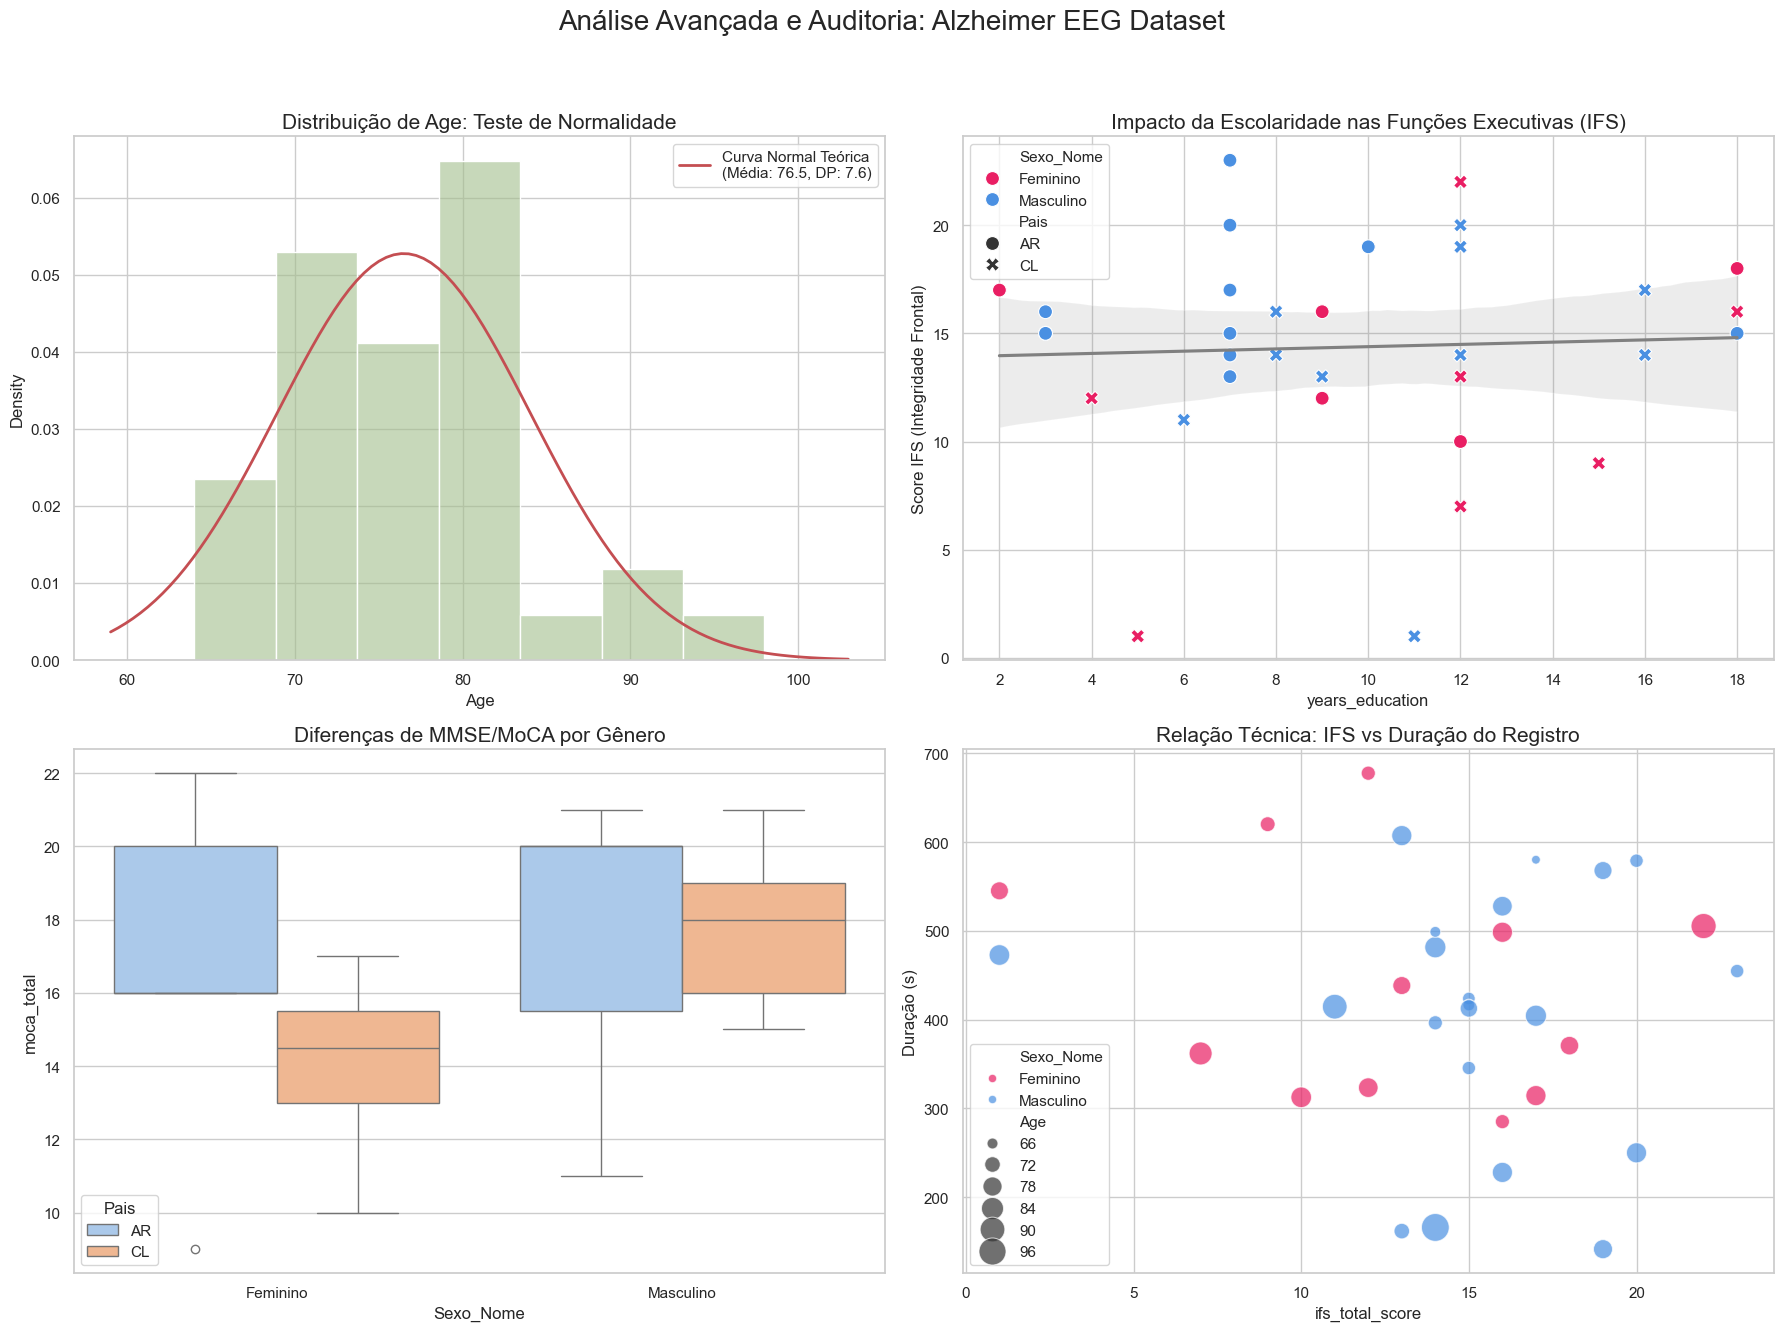

In [18]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import warnings

warnings.filterwarnings('ignore')

# 1. Caminho e Carga
caminho_raiz = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer"
file_path = os.path.join(caminho_raiz, "metadados_propios_eeg_alzheimer.csv")

try:
    df = pd.read_csv(file_path)
    df['Sexo_Nome'] = df['sex'].map({0: 'Masculino', 1: 'Feminino'})

    # 2. Configuração Visual
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    paleta_sexo = {'Masculino': '#4A90E2', 'Feminino': '#E91E63'}

    # --- NOVO GRAFICO 1: Teste Visual de Normalidade (Ex: Idade) ---
    col_alvo = 'Age' # Você pode trocar por 'moca_total' ou 'ifs_total_score'
    dados = df[col_alvo].dropna()
    
    # Plot do Histograma Real
    sns.histplot(dados, kde=False, stat="density", ax=axes[0,0], color='#A3BE8C', alpha=0.6)
    
    # Criando a Curva Normal Teórica (Gauss) para comparação
    mu, std = dados.mean(), dados.std()
    x = np.linspace(dados.min() - 5, dados.max() + 5, 100)
    p = norm.pdf(x, mu, std)
    
    axes[0,0].plot(x, p, 'r', linewidth=2, label=f'Curva Normal Teórica\n(Média: {mu:.1f}, DP: {std:.1f})')
    axes[0,0].set_title(f'Distribuição de {col_alvo}: Teste de Normalidade', fontsize=15)
    axes[0,0].legend()

    # --- GRAFICO 2: IFS Score vs Escolaridade (Explicando Funções Executivas) ---
    sns.regplot(data=df, x='years_education', y='ifs_total_score', scatter=False, ax=axes[0,1], color='gray')
    sns.scatterplot(data=df, x='years_education', y='ifs_total_score', hue='Sexo_Nome', 
                    style='Pais', s=100, palette=paleta_sexo, ax=axes[0,1])
    axes[0,1].set_title('Impacto da Escolaridade nas Funções Executivas (IFS)', fontsize=15)
    axes[0,1].set_ylabel('Score IFS (Integridade Frontal)')

    # --- GRAFICO 3: Severidade Cognitiva por Gênero ---
    sns.boxplot(data=df, x='Sexo_Nome', y='moca_total', hue='Pais', ax=axes[1,0], palette='pastel')
    axes[1,0].set_title('Diferenças de MMSE/MoCA por Gênero', fontsize=15)

    # --- GRAFICO 4: Auditoria de Sinal vs IFS ---
    sns.scatterplot(data=df, x='ifs_total_score', y='Duração (s)', hue='Sexo_Nome', 
                    size='Age', sizes=(40, 400), alpha=0.7, palette=paleta_sexo, ax=axes[1,1])
    axes[1,1].set_title('Relação Técnica: IFS vs Duração do Registro', fontsize=15)

    plt.suptitle('Análise Avançada e Auditoria: Alzheimer EEG Dataset', fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except Exception as e:
    print(f"Erro: {e}")

**2-B) DADOS DO EEG**

In [24]:
"""
================================================================================
  AUDITORIA NEUROFISIOLÓGICA — EXTRAÇÃO E VISUALIZAÇÃO DE FEATURES EEG
  Projeto: Alzheimer Detection | NeuroComp/NUTES
================================================================================
  Famílias cobertas:
    1. Potência Relativa por Banda          (Delta, Theta, Alpha, Beta)
    2. Potência por Região Cortical         (Frontal, Temporal, Parietal, Occipital)
    3. Assimetria Alpha Frontal             (ln F4 – ln F3)
    4. Razões Espectrais                    (Theta/Alpha, Delta/Alpha, (Delta+Theta)/(Alpha+Beta))
    5. Entropia Espectral                   (por canal → média global)
    6. Parâmetros de Hjorth                 (Atividade, Mobilidade, Complexidade)
    7. Coerência Inter-hemisférica          (pares simétricos por banda)
================================================================================
"""

import mne
import numpy as np
import pandas as pd
import os
import glob
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import shapiro
from scipy.signal import coherence

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURAÇÃO GLOBAL
# ──────────────────────────────────────────────────────────────────────────────
CAMINHO_RAIZ = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer"

BANDAS = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta":  (13, 30),
}

# Mapeamento de regiões para canais EEG padrão (10-20 / 10-10)
# Ajuste conforme os canais presentes no seu dataset
REGIOES = {
    "Frontal":   ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz", "AF3", "AF4"],
    "Temporal":  ["T3", "T4", "T5", "T6", "T7", "T8", "TP7", "TP8"],
    "Parietal":  ["P3", "P4", "P7", "P8", "Pz", "CP3", "CP4", "CPz"],
    "Occipital": ["O1", "O2", "Oz"],
    "Central":   ["C3", "C4", "Cz", "FC3", "FC4", "FCz"],
}

# Pares para coerência inter-hemisférica (esquerda → direita)
PARES_COERENCIA = [
    ("F3", "F4"), ("T3", "T4"), ("P3", "P4"), ("O1", "O2"), ("C3", "C4"),
]

PALETTE = {"AR": "#E76F51", "CL": "#2A9D8F"}   # AD vs Controle

# ──────────────────────────────────────────────────────────────────────────────
# UTILITÁRIOS
# ──────────────────────────────────────────────────────────────────────────────

def _stat_line(series: pd.Series) -> str:
    """Retorna média±DP ou mediana[IQR] dependendo da normalidade (Shapiro-Wilk)."""
    data = series.dropna()
    if len(data) < 3:
        return "n insuficiente"
    _, p = shapiro(data)
    cv = (data.std() / data.mean() * 100) if data.mean() != 0 else float("nan")
    if p > 0.05:
        return (f"Média {data.mean():.4f} ± {data.std():.4f} | "
                f"Min–Max {data.min():.4f}–{data.max():.4f} | CV {cv:.1f}%")
    else:
        return (f"Mediana {data.median():.4f} "
                f"[{data.quantile(0.25):.4f}–{data.quantile(0.75):.4f}] | "
                f"Min–Max {data.min():.4f}–{data.max():.4f} | CV {cv:.1f}%")


def _cabecalho(titulo: str) -> None:
    print(f"\n{'':=<70}")
    print(f"  {titulo}")
    print(f"{'':=<70}")


def _canais_disponiveis(raw: mne.io.BaseRaw, lista: list[str]) -> list[str]:
    """Filtra apenas os canais presentes no arquivo atual."""
    return [c for c in lista if c in raw.ch_names]


# ──────────────────────────────────────────────────────────────────────────────
# FUNÇÕES DE EXTRAÇÃO POR FAMÍLIA
# ──────────────────────────────────────────────────────────────────────────────

def extrair_potencia_banda(raw: mne.io.BaseRaw) -> dict:
    """Família 1 — Potência relativa global por banda."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)
    psd_total = np.sum(psds, axis=-1, keepdims=True)  # shape (n_ch, 1)

    feats = {}
    for banda, (fmin, fmax) in BANDAS.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        pot_rel = (np.sum(psds[:, mask], axis=-1) / psd_total[:, 0]).mean()
        feats[f"Band_{banda}"] = float(pot_rel)
    return feats


def extrair_potencia_regional(raw: mne.io.BaseRaw) -> dict:
    """Família 2 — Potência relativa por região cortical × banda."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)
    psd_total = psds.sum()

    feats = {}
    for regiao, canais in REGIOES.items():
        ch_ok = _canais_disponiveis(raw, canais)
        if not ch_ok:
            continue
        idxs = [raw.ch_names.index(c) for c in ch_ok]
        psds_reg = psds[idxs, :]
        for banda, (fmin, fmax) in BANDAS.items():
            mask = (freqs >= fmin) & (freqs <= fmax)
            pot_rel = np.sum(psds_reg[:, mask]) / psd_total
            feats[f"Reg_{regiao}_{banda}"] = float(pot_rel)
    return feats


def extrair_assimetria_alpha(raw: mne.io.BaseRaw) -> dict:
    """Família 3 — Assimetria Alpha Frontal: ln(F4) – ln(F3).
       Valores positivos → maior ativação esquerda (F3) = motivação/approach.
       Valores negativos → maior ativação direita  (F4) = retirada/aversão."""
    feats = {}
    for par_esq, par_dir in [("F3", "F4"), ("O1", "O2")]:
        if par_esq not in raw.ch_names or par_dir not in raw.ch_names:
            continue
        psd_obj = raw.compute_psd(
            method="multitaper", fmin=8, fmax=13,
            picks=[par_esq, par_dir], verbose=False
        )
        psds, _ = psd_obj.get_data(return_freqs=True)
        ln_esq = np.log(psds[0].mean() + 1e-12)
        ln_dir = np.log(psds[1].mean() + 1e-12)
        nome = "Front" if par_esq == "F3" else "Occip"
        feats[f"Assimetria_Alpha_{nome}"] = float(ln_dir - ln_esq)
    return feats


def extrair_razoes_espectrais(raw: mne.io.BaseRaw) -> dict:
    """Família 4 — Razões espectrais sensíveis a disfunções cognitivas."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)

    def pot(fmin, fmax):
        mask = (freqs >= fmin) & (freqs <= fmax)
        return psds[:, mask].sum(axis=-1).mean()

    delta = pot(*BANDAS["Delta"])
    theta = pot(*BANDAS["Theta"])
    alpha = pot(*BANDAS["Alpha"])
    beta  = pot(*BANDAS["Beta"])

    feats = {
        "Razao_Theta_Alpha":      float(theta / (alpha + 1e-12)),
        "Razao_Delta_Alpha":      float(delta / (alpha + 1e-12)),
        "Razao_SlowFast":         float((delta + theta) / (alpha + beta + 1e-12)),
        "Razao_Theta_Beta":       float(theta / (beta + 1e-12)),
    }
    return feats


def extrair_entropia_espectral(raw: mne.io.BaseRaw) -> dict:
    """Família 5 — Entropia espectral (média global e por banda).
       Quantifica irregularidade/imprevisibilidade do sinal."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)

    # Normaliza cada canal para distribuição de probabilidade
    p = psds / (psds.sum(axis=-1, keepdims=True) + 1e-12)
    ent_por_canal = -np.sum(p * np.log2(p + 1e-12), axis=-1)

    feats = {"Entropia_Espectral_Global": float(ent_por_canal.mean())}

    # Entropia restrita a cada banda
    for banda, (fmin, fmax) in BANDAS.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        p_banda = psds[:, mask] / (psds[:, mask].sum(axis=-1, keepdims=True) + 1e-12)
        ent_banda = -np.sum(p_banda * np.log2(p_banda + 1e-12), axis=-1)
        feats[f"Entropia_{banda}"] = float(ent_banda.mean())

    return feats


def extrair_hjorth(raw: mne.io.BaseRaw) -> dict:
    """Família 6 — Parâmetros de Hjorth (média global sobre todos os canais).
       - Atividade   : variância do sinal (potência)
       - Mobilidade  : √(var(1ª deriv) / var(sinal))
       - Complexidade: Mobilidade(1ª deriv) / Mobilidade(sinal)"""
    data = raw.get_data()  # shape: (n_ch, n_samples)

    atividade = np.var(data, axis=-1).mean()

    d1 = np.diff(data, axis=-1)
    mobilidade = np.sqrt(np.var(d1, axis=-1) / (np.var(data, axis=-1) + 1e-12)).mean()

    d2 = np.diff(d1, axis=-1)
    mob_d1 = np.sqrt(np.var(d2, axis=-1) / (np.var(d1, axis=-1) + 1e-12)).mean()
    complexidade = mob_d1 / (mobilidade + 1e-12)

    return {
        "Hjorth_Atividade":    float(atividade),
        "Hjorth_Mobilidade":   float(mobilidade),
        "Hjorth_Complexidade": float(complexidade),
    }


def extrair_coerencia(raw: mne.io.BaseRaw) -> dict:
    """Família 7 — Coerência inter-hemisférica por par × banda.
       Mede sincronização funcional entre hemisfério esquerdo e direito."""
    sfreq = raw.info["sfreq"]
    feats = {}

    for ch_esq, ch_dir in PARES_COERENCIA:
        if ch_esq not in raw.ch_names or ch_dir not in raw.ch_names:
            continue
        sig_esq = raw.get_data(picks=[ch_esq])[0]
        sig_dir = raw.get_data(picks=[ch_dir])[0]

        f_coh, Cxy = coherence(sig_esq, sig_dir, fs=sfreq, nperseg=int(sfreq * 2))

        for banda, (fmin, fmax) in BANDAS.items():
            mask = (f_coh >= fmin) & (f_coh <= fmax)
            coh_media = Cxy[mask].mean() if mask.any() else np.nan
            par_nome = f"{ch_esq}{ch_dir}"
            feats[f"Coh_{par_nome}_{banda}"] = float(coh_media)

    return feats


# ──────────────────────────────────────────────────────────────────────────────
# LOOP PRINCIPAL DE EXTRAÇÃO
# ──────────────────────────────────────────────────────────────────────────────

def extrair_todas_features(df_final: pd.DataFrame) -> pd.DataFrame:
    todos_os_sets = glob.glob(
        os.path.join(CAMINHO_RAIZ, "**", "*.set"), recursive=True
    )
    mapeamento = {os.path.basename(p): p for p in todos_os_sets}
    df_final = df_final.copy()
    df_final["Caminho_Completo"] = df_final["Arquivo"].map(mapeamento)

    print(f"\n🚀 Iniciando extração EEG para {len(df_final)} sujeitos...")
    features_list = []

    EXTRACTORS = [
        ("Potência/Banda",     extrair_potencia_banda),
        ("Potência/Região",    extrair_potencia_regional),
        ("Assimetria Alpha",   extrair_assimetria_alpha),
        ("Razões Espectrais",  extrair_razoes_espectrais),
        ("Entropia Espectral", extrair_entropia_espectral),
        ("Hjorth",             extrair_hjorth),
        ("Coerência",          extrair_coerencia),
    ]

    for idx, row in df_final.iterrows():
        caminho = row.get("Caminho_Completo")
        if pd.isna(caminho) or not os.path.exists(str(caminho)):
            print(f"  ⚠️  Arquivo não encontrado: {row['Arquivo']}")
            continue
        try:
            raw = mne.io.read_raw_eeglab(caminho, preload=True, verbose=False)
            raw.filter(0.5, 45, verbose=False)

            sujeito_feats = {"Arquivo": row["Arquivo"]}
            for nome_fam, fn in EXTRACTORS:
                try:
                    sujeito_feats.update(fn(raw))
                except Exception as e_fam:
                    print(f"    ⚠️  [{nome_fam}] {row['Arquivo']}: {e_fam}")

            features_list.append(sujeito_feats)
            n = idx + 1
            if n % 5 == 0 or n == len(df_final):
                print(f"  ✅ {n}/{len(df_final)} sujeitos processados")

        except Exception as e:
            print(f"  ❌ Erro crítico em {row['Arquivo']}: {e}")

    df_eeg = pd.DataFrame(features_list)
    return pd.merge(df_final, df_eeg, on="Arquivo", how="left")


# ──────────────────────────────────────────────────────────────────────────────
# AUDITORIA ESTATÍSTICA POR FAMÍLIA
# ──────────────────────────────────────────────────────────────────────────────

FAMILIAS_COLS = {
    "1 — Potência Relativa por Banda": [f"Band_{b}" for b in BANDAS],
    "2 — Potência por Região × Banda": [
        f"Reg_{r}_{b}" for r in REGIOES for b in BANDAS
    ],
    "3 — Assimetria Alpha Frontal": [
        "Assimetria_Alpha_Front", "Assimetria_Alpha_Occip"
    ],
    "4 — Razões Espectrais": [
        "Razao_Theta_Alpha", "Razao_Delta_Alpha",
        "Razao_SlowFast",    "Razao_Theta_Beta",
    ],
    "5 — Entropia Espectral": [
        "Entropia_Espectral_Global"
    ] + [f"Entropia_{b}" for b in BANDAS],
    "6 — Parâmetros de Hjorth": [
        "Hjorth_Atividade", "Hjorth_Mobilidade", "Hjorth_Complexidade"
    ],
    "7 — Coerência Inter-hemisférica": [
        f"Coh_{ch_e}{ch_d}_{b}"
        for ch_e, ch_d in PARES_COERENCIA
        for b in BANDAS
    ],
}


def auditoria_estatistica(df: pd.DataFrame) -> None:
    for familia, cols in FAMILIAS_COLS.items():
        cols_ok = [c for c in cols if c in df.columns]
        if not cols_ok:
            continue
        _cabecalho(f"FAMÍLIA {familia}")
        for col in cols_ok:
            linha = _stat_line(df[col])
            print(f"  {col:<40} {linha}")


# ──────────────────────────────────────────────────────────────────────────────
# VISUALIZAÇÕES
# ──────────────────────────────────────────────────────────────────────────────

def _melt_familia(df: pd.DataFrame, cols: list[str], valor: str) -> pd.DataFrame:
    cols_ok = [c for c in cols if c in df.columns]
    return df.melt(id_vars=["Pais"], value_vars=cols_ok,
                   var_name="Feature", value_name=valor)


def plot_familia_1(df: pd.DataFrame) -> None:
    """Boxplot de potência relativa por banda (AR vs CL)."""
    cols = [f"Band_{b}" for b in BANDAS]
    df_m = _melt_familia(df, cols, "Potência Relativa")
    df_m["Banda"] = df_m["Feature"].str.replace("Band_", "", regex=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df_m, x="Banda", y="Potência Relativa",
                hue="Pais", palette=PALETTE, ax=ax, width=0.55,
                order=list(BANDAS.keys()))
    sns.stripplot(data=df_m, x="Banda", y="Potência Relativa",
                  hue="Pais", palette=PALETTE, ax=ax,
                  dodge=True, size=3, alpha=0.5,
                  order=list(BANDAS.keys()), legend=False)
    ax.set_title("Família 1 — Potência Relativa por Banda (AR vs CL)", fontweight="bold")
    ax.set_ylabel("Potência Relativa Normalizada")
    ax.legend(title="Grupo")
    plt.tight_layout()
    plt.savefig("audit_F1_potencia_banda.png", dpi=150)
    plt.show()


def plot_familia_2(df: pd.DataFrame) -> None:
    """Heatmap de potência regional — média por grupo."""
    grupos = df["Pais"].unique()
    fig, axes = plt.subplots(1, len(grupos), figsize=(14, 5), sharey=True)

    for ax, grupo in zip(axes, grupos):
        df_g = df[df["Pais"] == grupo]
        matriz = {}
        for regiao in REGIOES:
            for banda in BANDAS:
                col = f"Reg_{regiao}_{banda}"
                if col in df_g.columns:
                    matriz.setdefault(regiao, {})[banda] = df_g[col].mean()
        df_heat = pd.DataFrame(matriz).T[list(BANDAS.keys())]
        sns.heatmap(df_heat, ax=ax, annot=True, fmt=".3f",
                    cmap="YlOrRd", linewidths=0.5,
                    vmin=0, vmax=df_heat.values.max() * 1.1)
        ax.set_title(f"Grupo: {grupo}", fontweight="bold")
        ax.set_xlabel("Banda")

    fig.suptitle("Família 2 — Potência Regional × Banda (média por grupo)",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("audit_F2_potencia_regional.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_familia_3(df: pd.DataFrame) -> None:
    """Violinplot de assimetria alpha (positivo = ativação esquerda)."""
    cols = ["Assimetria_Alpha_Front", "Assimetria_Alpha_Occip"]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return
    df_m = _melt_familia(df, cols_ok, "Assimetria (ln R – ln L)")
    df_m["Região"] = df_m["Feature"].str.replace("Assimetria_Alpha_", "", regex=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.violinplot(data=df_m, x="Região", y="Assimetria (ln R – ln L)",
                   hue="Pais", palette=PALETTE, split=True, inner="quart", ax=ax)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="Simetria")
    ax.set_title("Família 3 — Assimetria Alpha Frontal / Occipital",
                 fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("audit_F3_assimetria_alpha.png", dpi=150)
    plt.show()


def plot_familia_4(df: pd.DataFrame) -> None:
    """Barras com IC para razões espectrais por grupo."""
    cols = ["Razao_Theta_Alpha", "Razao_Delta_Alpha",
            "Razao_SlowFast", "Razao_Theta_Beta"]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return
    df_m = _melt_familia(df, cols_ok, "Razão")
    df_m["Razão"] = df_m["Feature"].str.replace("Razao_", "", regex=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=df_m, x="Razão", y="Razão",
                hue="Pais", palette=PALETTE,
                estimator=np.median, errorbar=("pi", 50), ax=ax)
    # Replot correto
    ax.cla()
    sns.barplot(data=df_m, x="Feature", y="Razão",
                hue="Pais", palette=PALETTE,
                estimator=np.median, errorbar=("pi", 50), ax=ax)
    ax.set_xticklabels([c.replace("Razao_", "").replace("_", "/")
                         for c in cols_ok], rotation=15)
    ax.set_title("Família 4 — Razões Espectrais (mediana + IC 50%)",
                 fontweight="bold")
    ax.set_ylabel("Valor da Razão")
    ax.legend(title="Grupo")
    plt.tight_layout()
    plt.savefig("audit_F4_razoes_espectrais.png", dpi=150)
    plt.show()


def plot_familia_5(df: pd.DataFrame) -> None:
    """KDE da entropia espectral por banda."""
    cols = ["Entropia_Espectral_Global"] + [f"Entropia_{b}" for b in BANDAS]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return

    n = len(cols_ok)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_ok):
        for grupo, cor in PALETTE.items():
            subset = df[df["Pais"] == grupo][col].dropna()
            if len(subset) > 1:
                sns.kdeplot(subset, ax=ax, label=grupo, color=cor, fill=True, alpha=0.35)
        ax.set_title(col.replace("Entropia_", ""), fontsize=9)
        ax.set_xlabel("Entropia (bits)")
        ax.legend(fontsize=7)

    fig.suptitle("Família 5 — Distribuição da Entropia Espectral",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig("audit_F5_entropia.png", dpi=150)
    plt.show()


def plot_familia_6(df: pd.DataFrame) -> None:
    """Boxplot dos três parâmetros de Hjorth lado a lado."""
    cols = ["Hjorth_Atividade", "Hjorth_Mobilidade", "Hjorth_Complexidade"]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return

    fig, axes = plt.subplots(1, len(cols_ok), figsize=(5 * len(cols_ok), 5))
    if len(cols_ok) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_ok):
        sns.boxplot(data=df, x="Pais", y=col,
                    palette=PALETTE, ax=ax, width=0.5)
        sns.stripplot(data=df, x="Pais", y=col,
                      palette=PALETTE, ax=ax, size=4, alpha=0.6)
        ax.set_title(col.replace("Hjorth_", ""), fontweight="bold")
        ax.set_xlabel("Grupo")

    fig.suptitle("Família 6 — Parâmetros de Hjorth", fontweight="bold")
    plt.tight_layout()
    plt.savefig("audit_F6_hjorth.png", dpi=150)
    plt.show()


def plot_familia_7(df: pd.DataFrame) -> None:
    """Heatmap de coerência média por par × banda, separado por grupo."""
    pares = [f"{ch_e}{ch_d}" for ch_e, ch_d in PARES_COERENCIA]
    grupos = df["Pais"].unique()
    bandas_list = list(BANDAS.keys())

    fig, axes = plt.subplots(1, len(grupos), figsize=(6 * len(grupos), 5),
                             sharey=True)
    if len(grupos) == 1:
        axes = [axes]

    for ax, grupo in zip(axes, grupos):
        df_g = df[df["Pais"] == grupo]
        matriz = pd.DataFrame(index=pares, columns=bandas_list, dtype=float)
        for par in pares:
            for banda in bandas_list:
                col = f"Coh_{par}_{banda}"
                if col in df_g.columns:
                    matriz.loc[par, banda] = df_g[col].mean()
        sns.heatmap(matriz.astype(float), ax=ax, annot=True, fmt=".3f",
                    cmap="Blues", linewidths=0.5, vmin=0, vmax=1)
        ax.set_title(f"Grupo: {grupo}", fontweight="bold")
        ax.set_xlabel("Banda")
        ax.set_ylabel("Par Inter-hemisférico")

    fig.suptitle("Família 7 — Coerência Inter-hemisférica Média",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("audit_F7_coerencia.png", dpi=150, bbox_inches="tight")
    plt.show()


def plotar_todas_familias(df: pd.DataFrame) -> None:
    print("\n📊 Gerando visualizações por família...")
    plot_familia_1(df)
    plot_familia_2(df)
    plot_familia_3(df)
    plot_familia_4(df)
    plot_familia_5(df)
    plot_familia_6(df)
    plot_familia_7(df)
    print("✅ Todas as figuras salvas.")


# ──────────────────────────────────────────────────────────────────────────────
# PONTO DE ENTRADA
# ──────────────────────────────────────────────────────────────────────────────
# Substitua `df_final` pelo seu DataFrame já carregado com colunas
# obrigatórias: 'Arquivo' e 'Pais' (ou equivalente ao grupo clínico).
#
# Exemplo de uso:
#
#   df_final = pd.read_csv("metadados.csv")          # carrega seus metadados
#   df_final = extrair_todas_features(df_final)       # extrai features EEG
#   auditoria_estatistica(df_final)                   # imprime tabela por família
#   plotar_todas_familias(df_final)                   # gera e salva os gráficos
#   df_final.to_csv("df_eeg_features_completo.csv", index=False)
# ──────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # df_final = pd.read_csv("metadados.csv")
    # df_final = extrair_todas_features(df_final)
    # auditoria_estatistica(df_final)
    # plotar_todas_familias(df_final)
    pass


🚀 Iniciando extração EEG para 35 sujeitos...
  ✅ 5/35 sujeitos processados
  ✅ 10/35 sujeitos processados
  ✅ 15/35 sujeitos processados
  ✅ 20/35 sujeitos processados
  ✅ 25/35 sujeitos processados
  ✅ 30/35 sujeitos processados
  ✅ 35/35 sujeitos processados

  FAMÍLIA 1 — Potência Relativa por Banda
  Band_Delta                               Média 0.2042 ± 0.0662 | Min–Max 0.0725–0.4180 | CV 32.4%
  Band_Theta                               Média 0.2193 ± 0.0864 | Min–Max 0.0883–0.4254 | CV 39.4%
  Band_Alpha                               Média 0.3279 ± 0.1218 | Min–Max 0.1302–0.7028 | CV 37.1%
  Band_Beta                                Média 0.2487 ± 0.0975 | Min–Max 0.1027–0.4866 | CV 39.2%

  FAMÍLIA 2 — Potência por Região × Banda
  Reg_Central_Delta                        Mediana 0.0026 [0.0018–0.0038] | Min–Max 0.0008–0.0171 | CV 85.5%
  Reg_Central_Theta                        Mediana 0.0029 [0.0022–0.0037] | Min–Max 0.0012–0.0070 | CV 43.6%
  Reg_Central_Alpha               

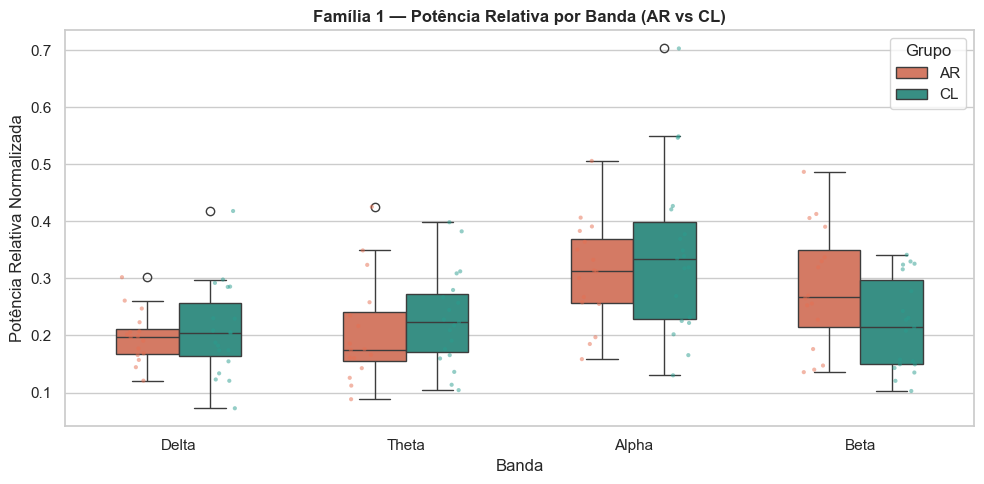

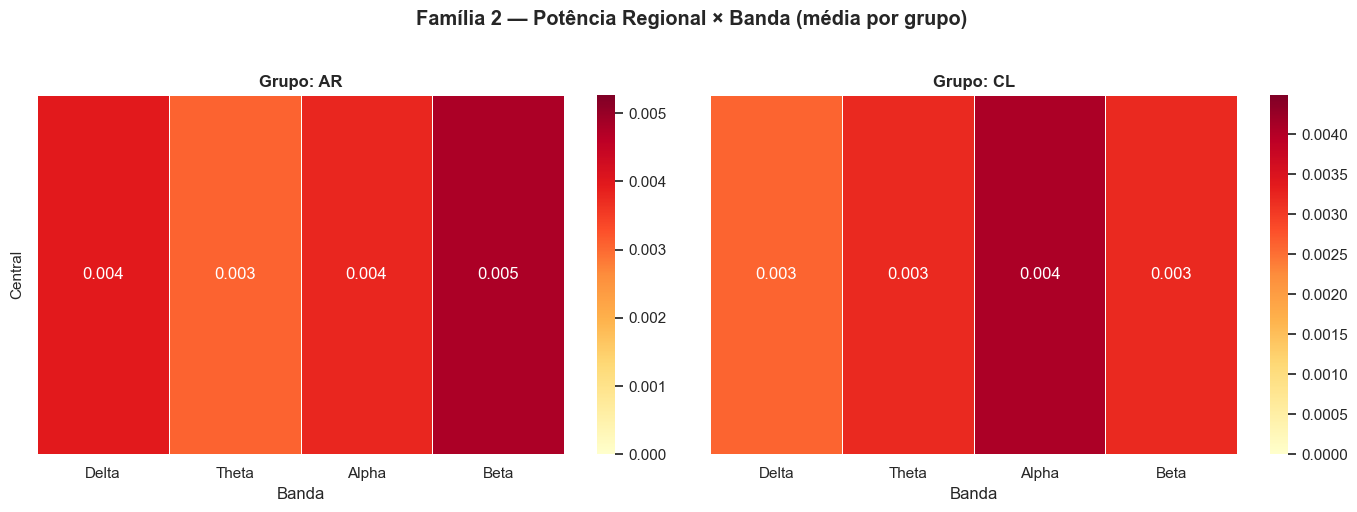

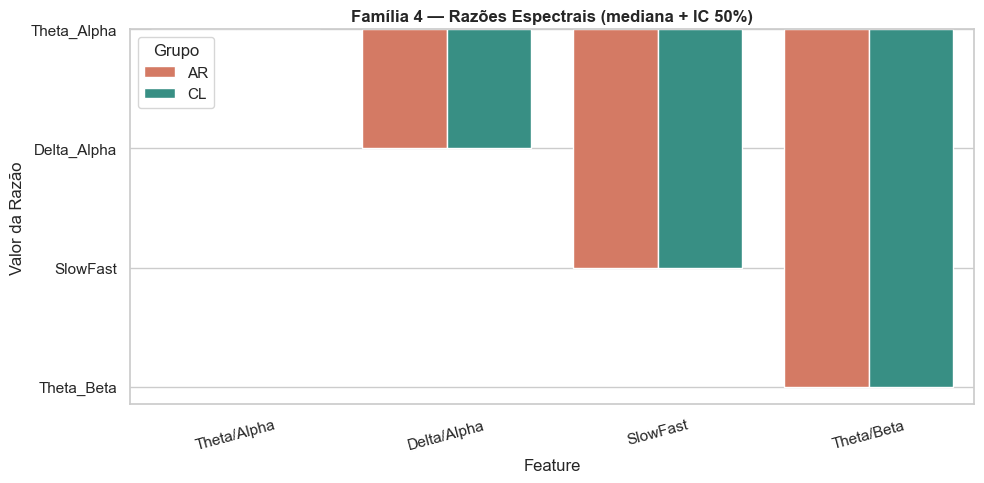

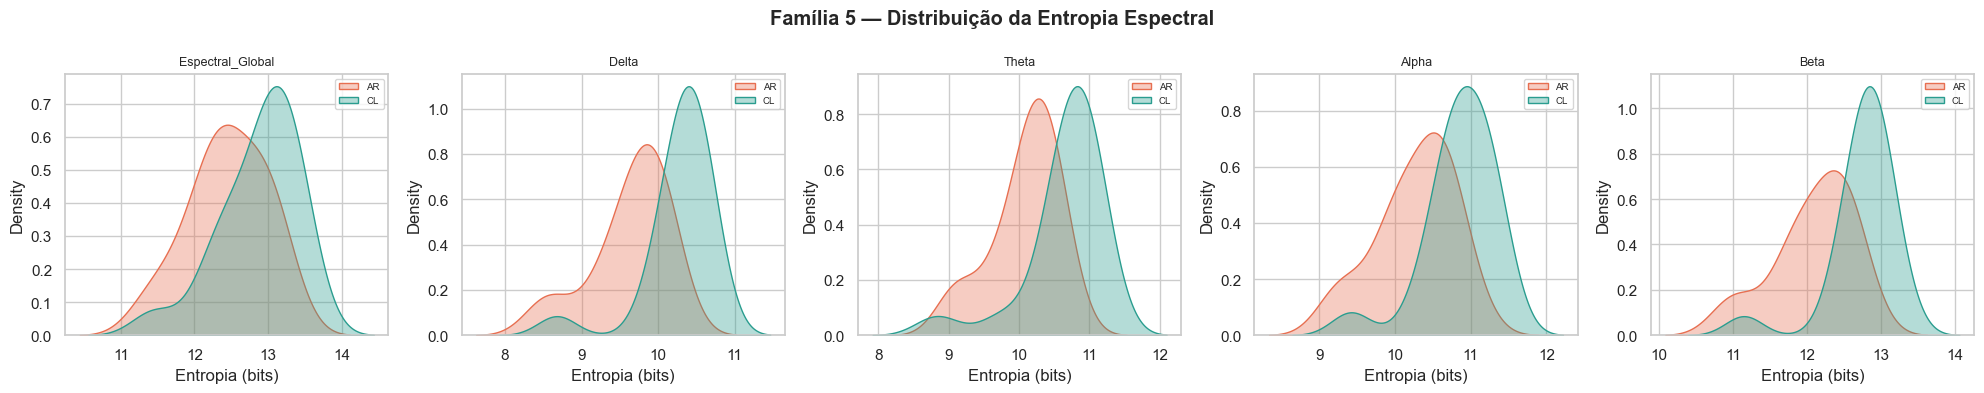

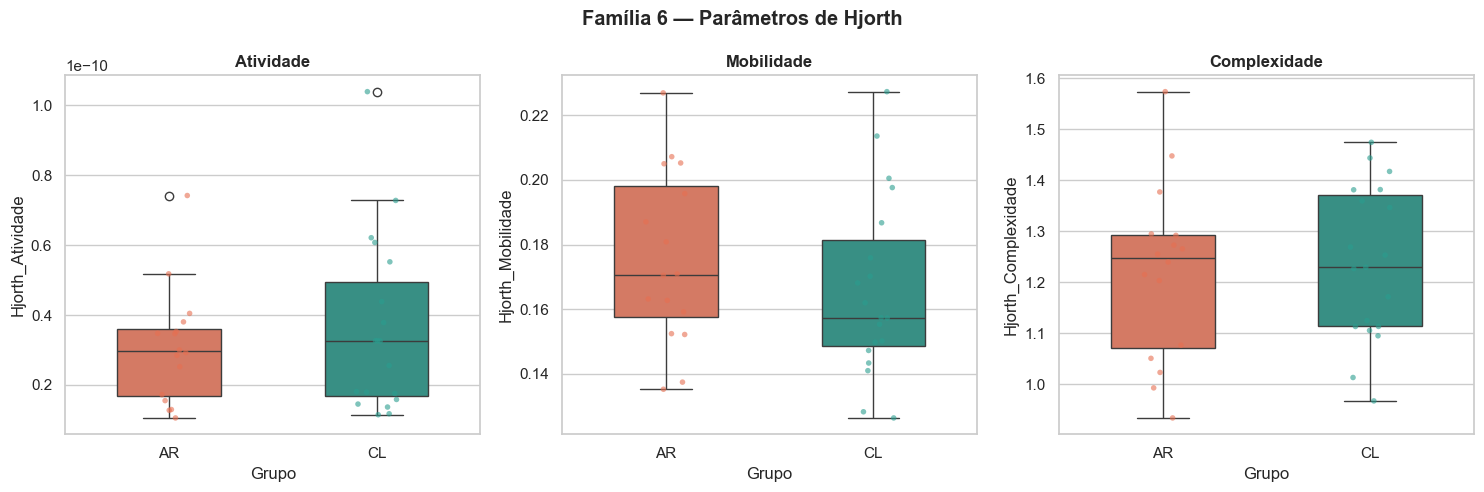

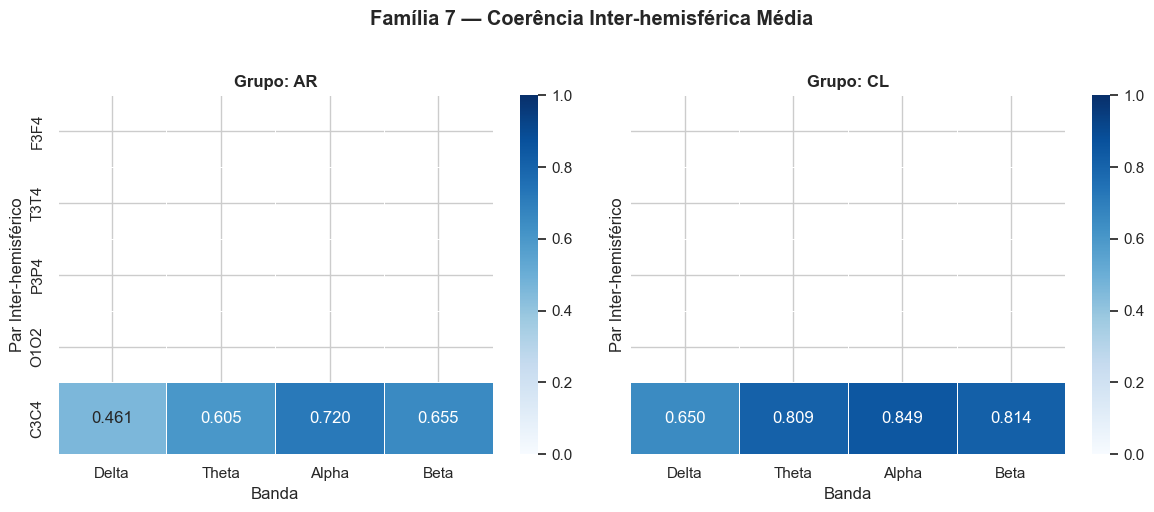

✅ Todas as figuras salvas.

✅ PROCESSO FINALIZADO! Confira a pasta do NUTES.


In [25]:
# Verifique se o df_final já está na memória, se não, carregue-o:
# df_final = pd.read_csv(os.path.join(CAMINHO_RAIZ, "metadados_propios_eeg_alzheimer.csv"))

# --- DISPARADOR DA AUDITORIA ---
df_eeg_completo = extrair_todas_features(df_final) # Extrai as 7 famílias
auditoria_estatistica(df_eeg_completo)            # Gera as tabelas
plotar_todas_familias(df_eeg_completo)            # Gera os 7 gráficos

# SALVAMENTO FINAL
caminho_save = os.path.join(CAMINHO_RAIZ, "df_auditado_final_alzheimer.csv")
df_eeg_completo.to_csv(caminho_save, index=False)

print(f"\n✅ PROCESSO FINALIZADO! Confira a pasta do NUTES.")

**2-C) Cruzamento Entre Dados de EEG, Cognitivos e Sociodemograficos**

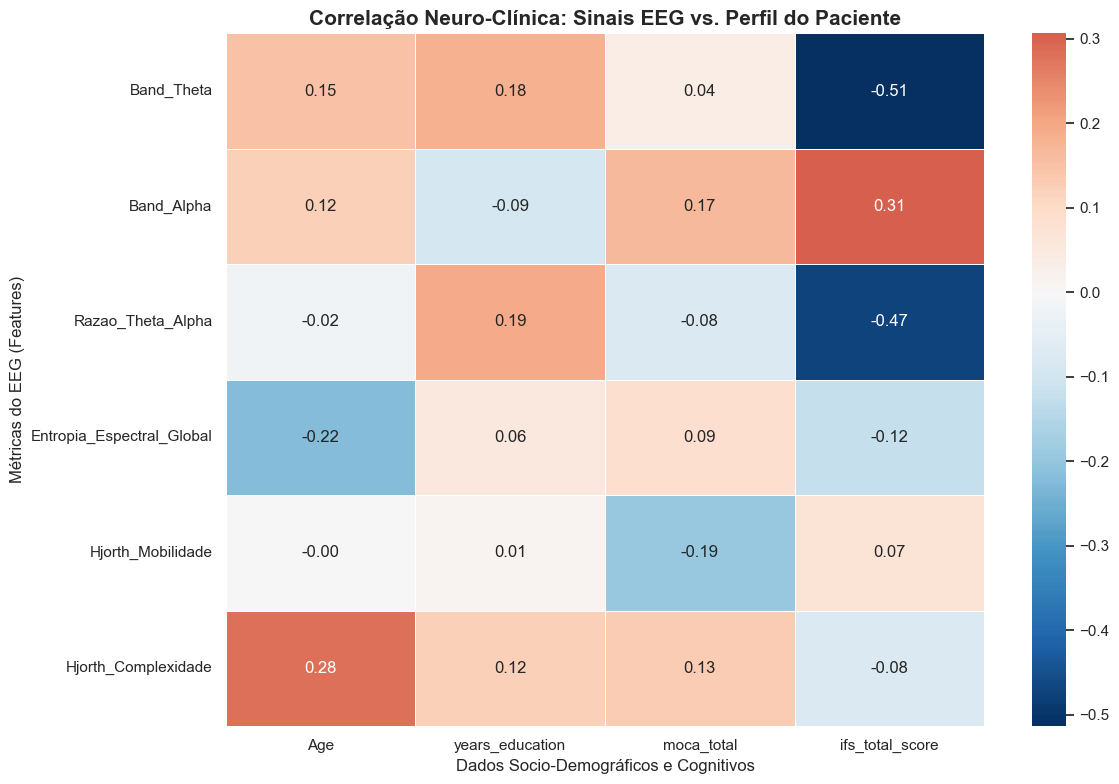

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleção das métricas principais para o cruzamento
cols_eeg = [
    'Band_Theta', 'Band_Alpha', 'Razao_Theta_Alpha', 
    'Entropia_Espectral_Global', 'Hjorth_Mobilidade', 'Hjorth_Complexidade'
]

cols_clinicas = ['Age', 'years_education', 'moca_total', 'ifs_total_score']

# 2. Cálculo da Matriz de Correlação (Spearman é melhor para dados clínicos/não-lineares)
corr_matrix = df_eeg_completo[cols_eeg + cols_clinicas].corr(method='spearman')

# 3. Filtrando apenas o cruzamento EEG vs CLÍNICA (Para não poluir o gráfico)
plt.figure(figsize=(12, 8))
subset_corr = corr_matrix.loc[cols_eeg, cols_clinicas]

sns.heatmap(subset_corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Correlação Neuro-Clínica: Sinais EEG vs. Perfil do Paciente', fontweight='bold', fontsize=15)
plt.xlabel('Dados Socio-Demográficos e Cognitivos')
plt.ylabel('Métricas do EEG (Features)')
plt.tight_layout()
plt.show()

In [9]:
df = pd.read_csv(r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer\df_auditado_final_alzheimer.csv")
print(df.columns.tolist())

['Arquivo', 'Pais', 'Duração (s)', 'Freq_Amostragem (Hz)', 'Canais_Info', 'Filtro_HP', 'Filtro_LP', 'Bad_Channels', 'path_x', 'id EEG_x', 'diagnosis_x', 'sex', 'Age', 'years_education', 'laterality', 'path_y', 'id EEG_y', 'diagnosis_y', 'moca_total', 'moca_visuospatial', 'moca_recog', 'moca_attention', 'moca_language', 'moca_abstraction', 'moca_memory', 'moca_orientation', 'ifs_total_score', 'ifs_motor_series', 'ifs_conflicting_instructions', 'ifs_motor_inhibition', 'ifs_digits', 'ifs_months', 'ifs_visual_wm', 'ifs_proverb', 'ifs_verbal_inhibition', 'mini_sea_fer', 'mini_sea_tom', 'emotion recog', 'Caminho_Completo', 'EEG_Power_Delta', 'EEG_Power_Theta', 'EEG_Power_Alpha', 'EEG_Power_Beta', 'Band_Delta', 'Band_Theta', 'Band_Alpha', 'Band_Beta', 'Reg_Central_Delta', 'Reg_Central_Theta', 'Reg_Central_Alpha', 'Reg_Central_Beta', 'Razao_Theta_Alpha', 'Razao_Delta_Alpha', 'Razao_SlowFast', 'Razao_Theta_Beta', 'Entropia_Espectral_Global', 'Entropia_Delta', 'Entropia_Theta', 'Entropia_Alpha',

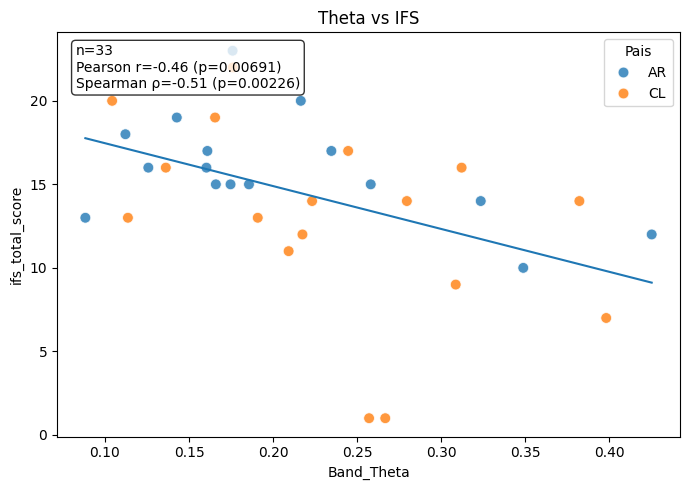

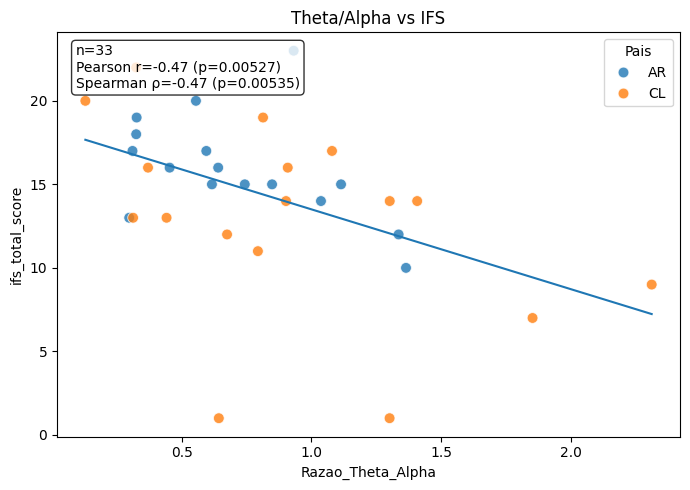

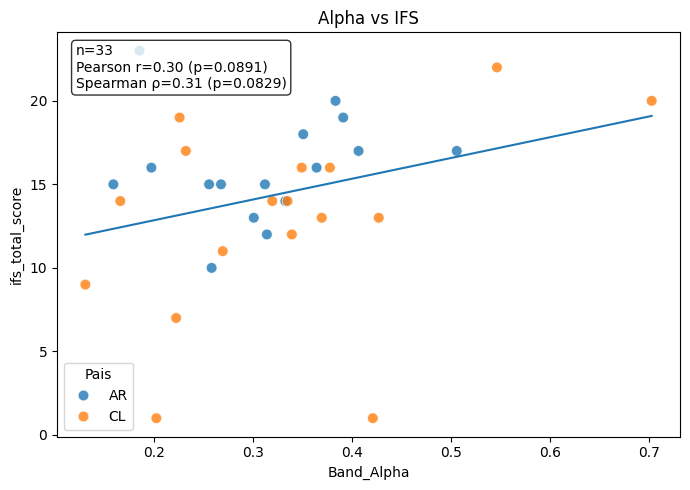

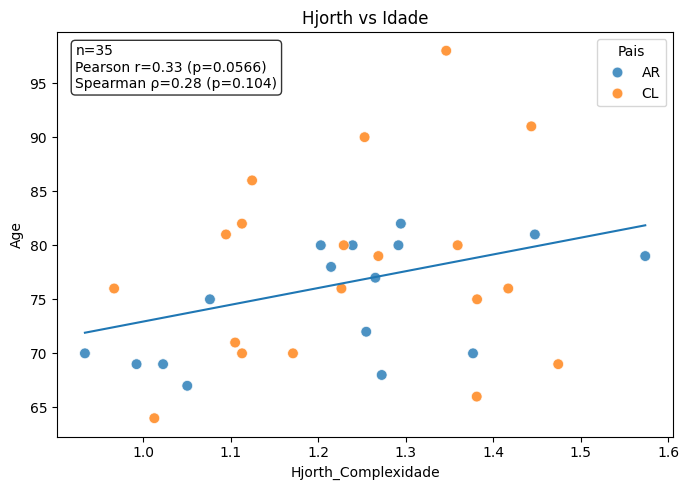

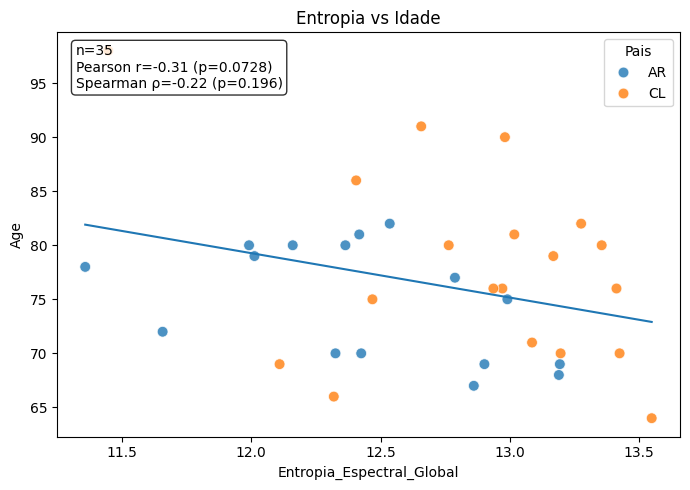

In [10]:
pairs = [
    ("Band_Theta", "ifs_total_score", "Theta vs IFS"),
    ("Razao_Theta_Alpha", "ifs_total_score", "Theta/Alpha vs IFS"),
    ("Band_Alpha", "ifs_total_score", "Alpha vs IFS"),
    ("Hjorth_Complexidade", "Age", "Hjorth vs Idade"),
    ("Entropia_Espectral_Global", "Age", "Entropia vs Idade"),
]

country_col = "Pais"

for x, y, t in pairs:
    plot_regression_safe(df, x, y, t, country_col)

In [11]:
import statsmodels.formula.api as smf

model = smf.ols(
    "ifs_total_score ~ Band_Theta + Age + years_education + C(Pais)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        ifs_total_score   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     3.242
Date:                Tue, 07 Apr 2026   Prob (F-statistic):             0.0264
Time:                        12:01:52   Log-Likelihood:                -92.596
No. Observations:                  33   AIC:                             195.2
Df Residuals:                      28   BIC:                             202.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          19.9744      7.955     

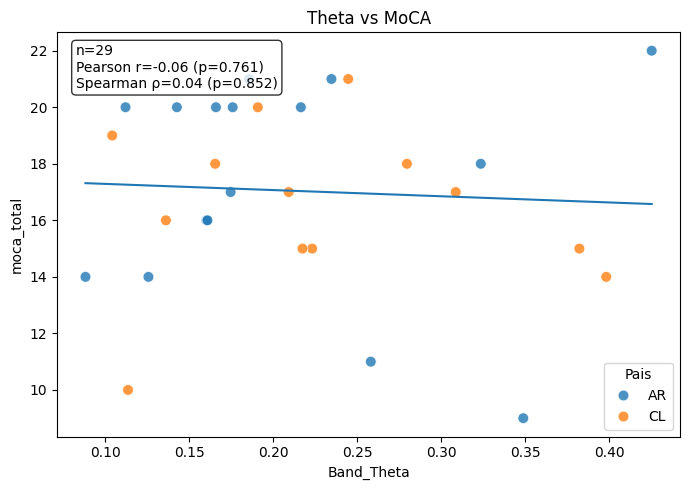

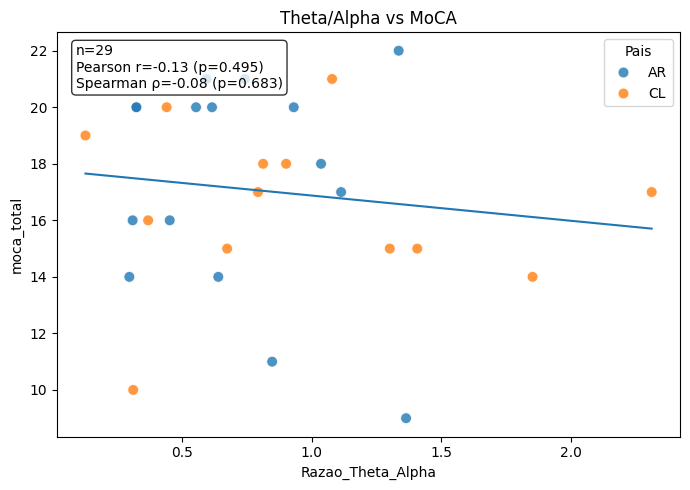

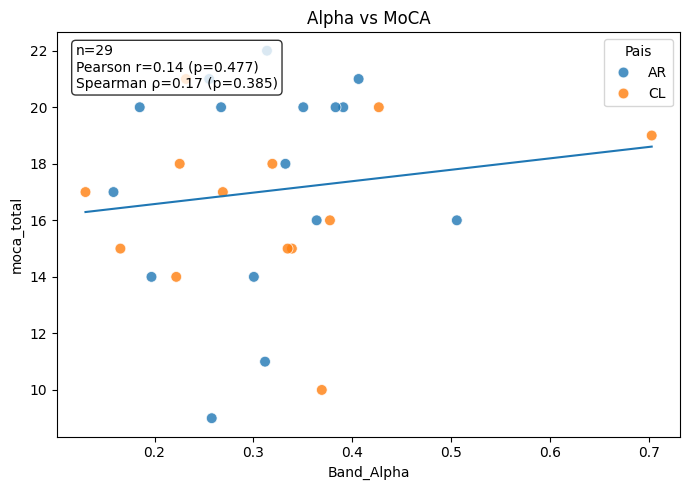

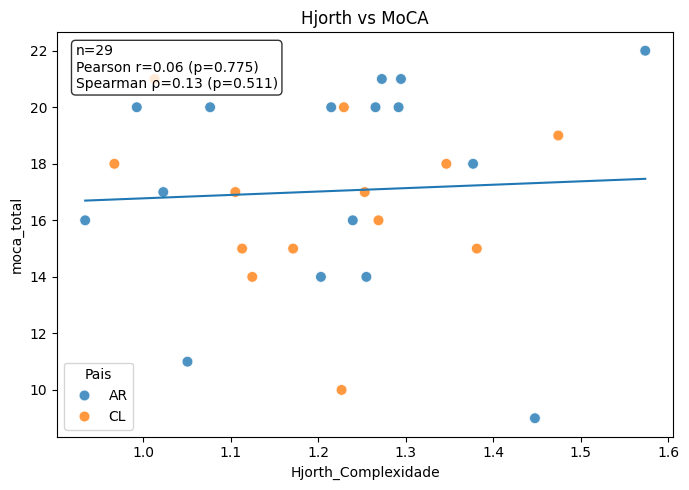

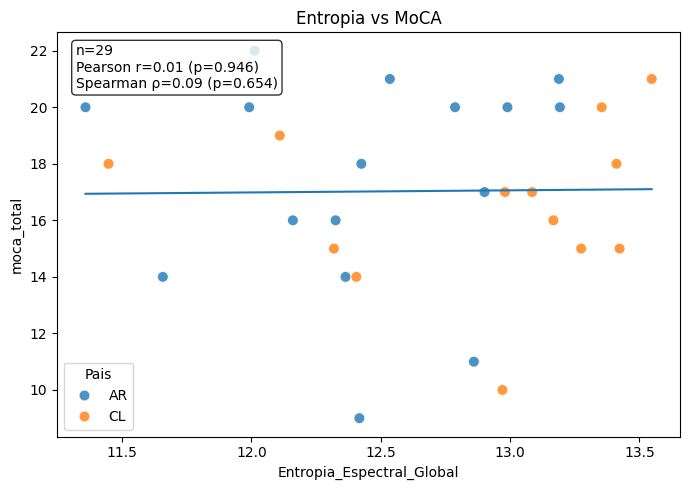

In [13]:
pairs_moca = [
    ("Band_Theta", "moca_total", "Theta vs MoCA"),
    ("Razao_Theta_Alpha", "moca_total", "Theta/Alpha vs MoCA"),
    ("Band_Alpha", "moca_total", "Alpha vs MoCA"),
    ("Hjorth_Complexidade", "moca_total", "Hjorth vs MoCA"),
    ("Entropia_Espectral_Global", "moca_total", "Entropia vs MoCA"),
]

country_col = "Pais"

for x, y, t in pairs_moca:
    plot_regression_safe(df, x, y, t, country_col)

In [14]:
import statsmodels.formula.api as smf

model_moca = smf.ols(
    "moca_total ~ Band_Theta + Age + years_education + C(Pais)",
    data=df
).fit()

print(model_moca.summary())

                            OLS Regression Results                            
Dep. Variable:             moca_total   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                 -0.091
Method:                 Least Squares   F-statistic:                    0.4158
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.796
Time:                        12:05:02   Log-Likelihood:                -75.216
No. Observations:                  29   AIC:                             160.4
Df Residuals:                      24   BIC:                             167.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          16.7075      6.888     

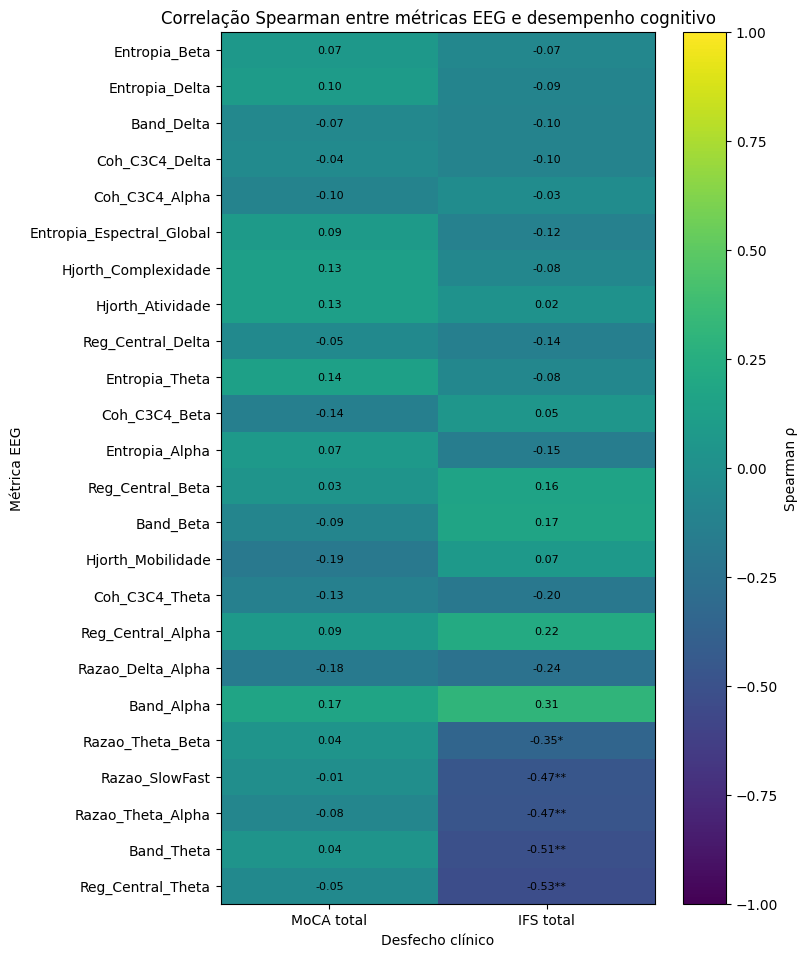

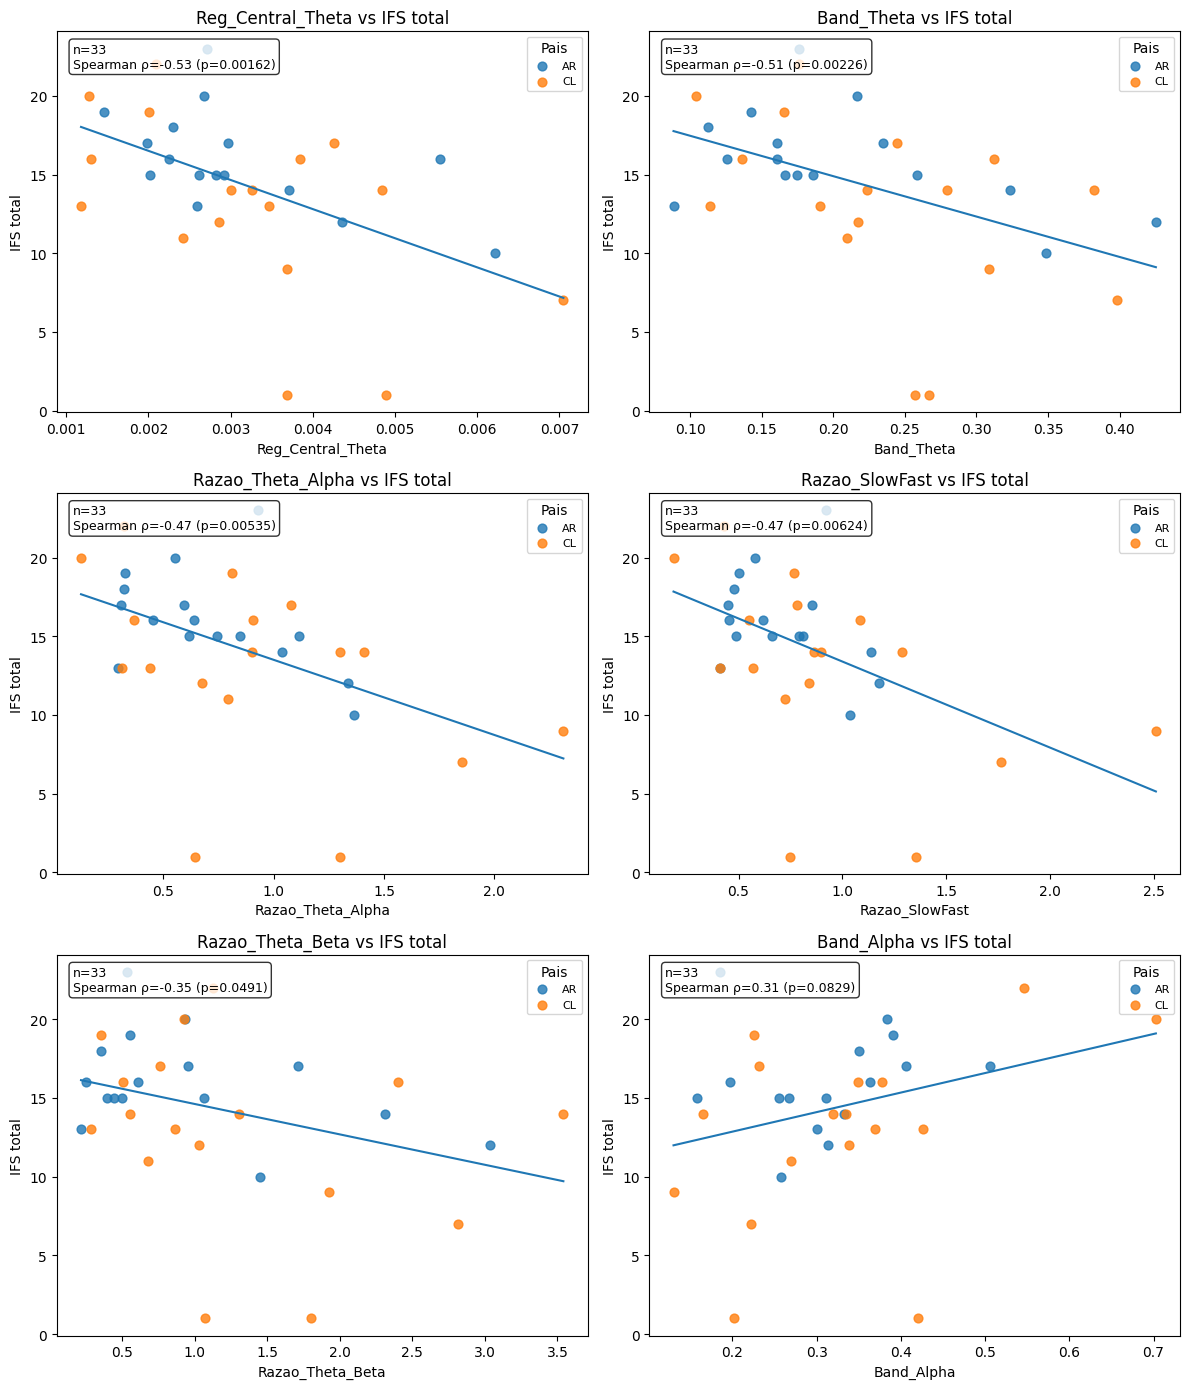

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# PREPARO
# ============================================================
# Assumindo que seu dataframe já está carregado em `df`
# Ex.: df = pd.read_csv(r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer\df_auditado_final_alzheimer.csv")

outcomes = ["moca_total", "ifs_total_score"]

# Pega automaticamente todas as métricas de EEG do pipeline
eeg_prefixes = ("Band_", "Reg_", "Razao_", "Entropia_", "Hjorth_", "Coh_", "Assimetria_")
eeg_cols = [c for c in df.columns if c.startswith(eeg_prefixes)]
eeg_cols = [c for c in eeg_cols if c not in outcomes]

# ============================================================
# 1) CORRELAÇÕES (SPEARMAN) EEG vs MOCA / IFS
# ============================================================
rows = []
for feat in eeg_cols:
    row = {"feature": feat}
    for out in outcomes:
        sub = df[[feat, out]].dropna()
        if len(sub) >= 3 and sub[feat].nunique() > 1 and sub[out].nunique() > 1:
            rho, p = spearmanr(sub[feat], sub[out])
            row[f"{out}_rho"] = rho
            row[f"{out}_p"] = p
            row[f"{out}_n"] = len(sub)
        else:
            row[f"{out}_rho"] = np.nan
            row[f"{out}_p"] = np.nan
            row[f"{out}_n"] = len(sub)
    rows.append(row)

res = pd.DataFrame(rows)

# Ordena pelas maiores correlações absolutas em qualquer um dos desfechos
res["max_abs_rho"] = res[["moca_total_rho", "ifs_total_score_rho"]].abs().max(axis=1)
res = res.sort_values("max_abs_rho").reset_index(drop=True)

# ============================================================
# 2) FIGURA 1 — HEATMAP EEG vs MOCA / IFS
# ============================================================
fig, ax = plt.subplots(figsize=(8, max(6, 0.32 * len(res) + 2)))

mat = res[["moca_total_rho", "ifs_total_score_rho"]].to_numpy()

im = ax.imshow(mat, aspect="auto", vmin=-1, vmax=1)

ax.set_xticks([0, 1])
ax.set_xticklabels(["MoCA total", "IFS total"])
ax.set_yticks(np.arange(len(res)))
ax.set_yticklabels(res["feature"])

ax.set_title("Correlação Spearman entre métricas EEG e desempenho cognitivo")
ax.set_xlabel("Desfecho clínico")
ax.set_ylabel("Métrica EEG")

# Anotações: rho e significância
for i in range(len(res)):
    for j, out in enumerate(outcomes):
        rho = res.loc[i, f"{out}_rho"]
        p = res.loc[i, f"{out}_p"]
        if pd.notna(rho):
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            txt = f"{rho:.2f}{sig}"
        else:
            txt = "NA"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spearman ρ")

plt.tight_layout()
plt.show()

# Salva a figura, se desejar
# fig.savefig("heatmap_eeg_moca_ifs.png", dpi=300, bbox_inches="tight")

# ============================================================
# 3) FIGURA 2 — TOP 6 ASSOCIAÇÕES EM SCATTER + REGRESSÃO
# ============================================================
top = res.sort_values("max_abs_rho", ascending=False).head(6).copy()

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for idx, (_, row) in enumerate(top.iterrows()):
    feat = row["feature"]

    # Decide qual desfecho é o mais forte para essa feature
    rho_moca = row["moca_total_rho"]
    rho_ifs = row["ifs_total_score_rho"]

    if pd.notna(rho_moca) and pd.notna(rho_ifs) and abs(rho_moca) >= abs(rho_ifs):
        out = "moca_total"
        out_label = "MoCA total"
        rho = rho_moca
        p = row["moca_total_p"]
    else:
        out = "ifs_total_score"
        out_label = "IFS total"
        rho = rho_ifs
        p = row["ifs_total_score_p"]

    sub = df[[feat, out, "Pais"] if "Pais" in df.columns else [feat, out]].dropna().copy()

    ax = axes[idx]
    if "Pais" in df.columns:
        for pais in sorted(sub["Pais"].dropna().unique()):
            d = sub[sub["Pais"] == pais]
            ax.scatter(d[feat], d[out], s=40, alpha=0.8, label=str(pais))
        ax.legend(title="Pais", fontsize=8)
    else:
        ax.scatter(sub[feat], sub[out], s=40, alpha=0.8)

    # Regressão linear simples só para visualização
    if len(sub) >= 2 and sub[feat].nunique() > 1:
        x = sub[feat].to_numpy()
        y = sub[out].to_numpy()
        b1, b0 = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = b1 * x_line + b0
        ax.plot(x_line, y_line)

    ax.set_title(f"{feat} vs {out_label}")
    ax.set_xlabel(feat)
    ax.set_ylabel(out_label)
    ax.text(
        0.03, 0.97,
        f"n={len(sub)}\nSpearman ρ={rho:.2f} (p={p:.3g})",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        fontsize=9
    )

# remove eixos vazios, se houver
for j in range(len(top), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Salva a figura, se desejar
# fig.savefig("top6_eeg_moca_ifs_scatter.png", dpi=300, bbox_inches="tight")

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer\df_auditado_final_alzheimer.csv")

# ============================================================
# CORE EEG FEATURES (alto valor clínico)
# ============================================================

features_core = [
    # Bandas (biomarcadores clássicos AD)
    "Band_Delta", "Band_Theta", "Band_Alpha", "Band_Beta",
    
    # Razões (MUITO importantes em AD)
    "Razao_Theta_Alpha",
    "Razao_Delta_Alpha",
    "Razao_SlowFast",
    
    # Complexidade do sinal
    "Entropia_Espectral_Global",
    "Hjorth_Complexidade",
    
    # Conectividade (mínimo essencial)
    "Coh_C3C4_Alpha",
    "Coh_C3C4_Theta"
]

# Targets cognitivos
targets = ["moca_total", "ifs_total_score"]

df_core = df[features_core + targets].dropna()
print("Shape final:", df_core.shape)

Shape final: (29, 13)


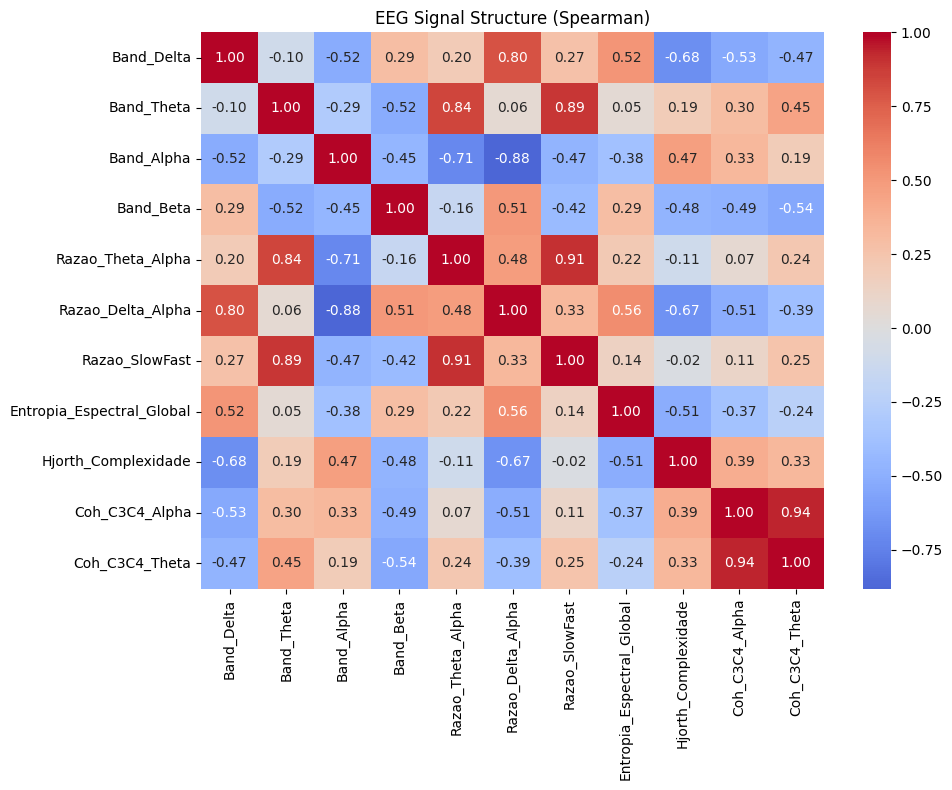

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_core[features_core].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("EEG Signal Structure (Spearman)")
plt.tight_layout()
plt.show()

# VERIFICANDO METADADOS DE SAUDÁVEIS

In [28]:
import mne
import os
import glob
import pandas as pd
import numpy as np
from collections import Counter
import warnings
from scipy.io import loadmat

warnings.filterwarnings('ignore')

def ler_eeg_flexivel(caminho_set):
    """
    Tenta ler um arquivo .set, primeiro com MNE (esperando .fdt),
    depois manualmente via loadmat caso o .fdt não exista.
    Retorna (raw, sucesso).
    """
    # Verifica se o .fdt correspondente existe
    fdt_path = caminho_set.replace('.set', '.fdt')
    if os.path.exists(fdt_path):
        try:
            raw = mne.io.read_raw_eeglab(caminho_set, preload=False, verbose=False)
            return raw, True
        except Exception as e:
            print(f"    MNE falhou mesmo com .fdt presente: {e}")
            # Continua para tentativa manual

    # Tentativa manual: carregar o .set como arquivo MATLAB
    try:
        mat = loadmat(caminho_set, struct_as_record=False, squeeze_me=True)
        # Identificar os campos comuns no EEGLAB
        if 'EEG' in mat:
            eeg = mat['EEG']
        else:
            # Tenta encontrar qualquer variável que contenha os dados
            for key in mat:
                if key not in ['__header__', '__version__', '__globals__']:
                    eeg = mat[key]
                    break
            else:
                raise ValueError("Estrutura EEG não encontrada no arquivo .set")
        
        # Extrair dados
        if hasattr(eeg, 'data'):
            data = eeg.data
        elif isinstance(eeg, dict) and 'data' in eeg:
            data = eeg['data']
        else:
            raise ValueError("Campo 'data' não encontrado")
        
        # Garantir que data seja 2D (canais x tempo)
        if data.ndim == 3:
            data = data.squeeze()  # remove dimensão extra
        if data.ndim != 2:
            raise ValueError(f"Formato de dados inesperado: {data.shape}")
        
        # Transpor se necessário (EEGLAB costuma ser canais x tempo)
        # O MNE espera (n_canais, n_tempos)
        if data.shape[0] > data.shape[1] and data.shape[1] < 100:
            data = data.T
        
        # Extrair frequência de amostragem
        if hasattr(eeg, 'srate'):
            sfreq = float(eeg.srate)
        elif isinstance(eeg, dict) and 'srate' in eeg:
            sfreq = float(eeg['srate'])
        else:
            sfreq = 256.0  # valor padrão, tentar extrair de outra forma
        
        # Extrair nomes dos canais
        if hasattr(eeg, 'chanlocs'):
            ch_names = [ch.labels if hasattr(ch, 'labels') else f'CH{i+1}' 
                        for i, ch in enumerate(eeg.chanlocs)]
        elif isinstance(eeg, dict) and 'chanlocs' in eeg:
            ch_names = [ch['labels'] if isinstance(ch, dict) else str(ch) 
                        for ch in eeg['chanlocs']]
        else:
            ch_names = [f'EEG{i+1:03d}' for i in range(data.shape[0])]
        
        # Criar info do MNE
        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
        raw = mne.io.RawArray(data, info, verbose=False)
        return raw, True
        
    except Exception as e:
        print(f"    Falha na leitura manual: {e}")
        return None, False


# 1. Configuração de Caminhos e Arquivos (saudáveis)
caminho_raiz = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_hc"
arq_demografico = os.path.join(caminho_raiz, "demographics_hc_eeg_data.csv")
arq_cognitivo = os.path.join(caminho_raiz, "cognition_hc_eeg_data.csv")

# 2. Carregamento de Metadados
try:
    df_demo = pd.read_csv(arq_demografico)
    df_cog = pd.read_csv(arq_cognitivo)
    
    def clean_id(df):
        col_id = [c for c in df.columns if 'id' in c.lower()][0]
        df[col_id] = df[col_id].astype(str).str.replace('sub-', '')
        return df, col_id

    df_demo, col_id_demo = clean_id(df_demo)
    df_cog, col_id_cog = clean_id(df_cog)
    print(f"✅ Dados externos carregados: {len(df_demo)} sujeitos saudáveis identificados.")
except Exception as e:
    print(f"❌ Erro ao carregar metadados CSV: {e}")

# 3. Processamento flexível dos arquivos .set
padrao_busca = os.path.join(caminho_raiz, "**", "*.set")
arquivos_eeg = glob.glob(padrao_busca, recursive=True)
lista_tecnica = []

print(f"🔄 Analisando {len(arquivos_eeg)} arquivos .set (modo flexível)...")

for caminho_arq in arquivos_eeg:
    nome_arq = os.path.basename(caminho_arq)
    origem = "AR" if r"\AR" in caminho_arq else "CL"
    
    print(f"  Processando {nome_arq} ...")
    raw, ok = ler_eeg_flexivel(caminho_arq)
    
    if not ok:
        print(f"    ⚠️ Não foi possível ler {nome_arq}, ignorando.")
        continue
    
    try:
        info = raw.info
        # Extrair ID do nome do arquivo
        id_limpo = nome_arq.split('_')[1].replace('sub-', '') if '_' in nome_arq else nome_arq.replace('sub-', '')
        
        total_ch = info['nchan']
        tipos = Counter(raw.get_channel_types())
        qtd_eeg = tipos.get('eeg', 0)
        
        if total_ch == qtd_eeg:
            info_canais = f"{total_ch} (Todos EEG)"
        else:
            outros = total_ch - qtd_eeg
            info_canais = f"{total_ch} ({qtd_eeg} EEG / {outros} Outros)"
        
        dados_tecnicos = {
            "ID_Merge": id_limpo,
            "Arquivo": nome_arq,
            "Pais": origem,
            "Duração (s)": round(raw.times[-1], 2),
            "Freq_Amostragem (Hz)": info['sfreq'],
            "Canais_Info": info_canais,
            "Filtro_HP": info.get('highpass'),
            "Filtro_LP": info.get('lowpass'),
            "Bad_Channels": len(info['bads'])
        }
        lista_tecnica.append(dados_tecnicos)
        print(f"    ✅ Sucesso! Duração: {dados_tecnicos['Duração (s)']}s, Canais: {info_canais}")
    except Exception as e:
        print(f"    ❌ Erro ao extrair metadados: {e}")

# 4. Fusão e salvamento (apenas se houver dados)
if lista_tecnica:
    df_tecnico = pd.DataFrame(lista_tecnica)
    df_final = pd.merge(df_tecnico, df_demo, left_on="ID_Merge", right_on=col_id_demo, how="left")
    df_final = pd.merge(df_final, df_cog, left_on="ID_Merge", right_on=col_id_cog, how="left")
    cols_remover = [col_id_demo, col_id_cog, "ID_Merge"]
    df_final = df_final.drop(columns=[c for c in cols_remover if c in df_final.columns])
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    
    caminho_salvamento = os.path.join(caminho_raiz, "metadados_propios_eeg_hc.csv")
    df_final.to_csv(caminho_salvamento, index=False)
    
    print("\n" + "="*80)
    print(f"SUCESSO! {len(lista_tecnica)} arquivos processados. Tabela salva em: {caminho_salvamento}")
    print("="*80 + "\n")
    display(df_final)
else:
    print("\n❌ Nenhum arquivo EEG foi processado com sucesso. Verifique se os arquivos .set contêm dados embutidos ou se os .fdt estão presentes.")

✅ Dados externos carregados: 46 sujeitos saudáveis identificados.
🔄 Analisando 46 arquivos .set (modo flexível)...
  Processando s6_sub-100012_rs_eeg.set ...
    ✅ Sucesso! Duração: 345.59s, Canais: 128 (Todos EEG)
  Processando s6_sub-100015_rs_eeg.set ...
    ✅ Sucesso! Duração: 410.14s, Canais: 128 (Todos EEG)
  Processando s6_sub-100018_rs_eeg.set ...
    ✅ Sucesso! Duração: 362.25s, Canais: 128 (Todos EEG)
  Processando s6_sub-10002_rs_eeg.set ...
    ✅ Sucesso! Duração: 364.42s, Canais: 128 (Todos EEG)
  Processando s6_sub-100020_rs_eeg.set ...
    ✅ Sucesso! Duração: 328.59s, Canais: 128 (Todos EEG)
  Processando s6_sub-100022_rs_eeg.set ...
    ✅ Sucesso! Duração: 445.59s, Canais: 128 (Todos EEG)
  Processando s6_sub-100024_rs_eeg.set ...
    ✅ Sucesso! Duração: 496.05s, Canais: 128 (Todos EEG)
  Processando s6_sub-100026_rs_eeg.set ...
    ✅ Sucesso! Duração: 410.83s, Canais: 128 (Todos EEG)
  Processando s6_sub-100028_rs_eeg.set ...
    ✅ Sucesso! Duração: 288.36s, Canais: 12

,Arquivo,Pais,Duração (s),Freq_Amostragem (Hz),Canais_Info,Filtro_HP,Filtro_LP,Bad_Channels,path_x,id EEG_x,diagnosis_x,sex,Age,years_education,laterality,path_y,id EEG_y,diagnosis_y,moca_total,moca_visuospatial,moca_recog,moca_attention,moca_language,moca_abstraction,moca_memory,moca_orientation,ifs_total_score,ifs_motor_series,ifs_conflicting_instructions,ifs_motor_inhibition,ifs_digits,ifs_months,ifs_visual_wm,ifs_proverb,ifs_verbal_inhibition,mini_sea_fer,mini_sea_tom,emotion recog
0,s6_sub-100012_rs_eeg.set,AR,345.59,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100012,CN,1,74,12,1,HC/AR,100012,CN,18.0,5.0,3.0,3.0,1.0,1.0,0.0,5.0,20.0,3.0,3.0,2.0,2.0,1.0,4.0,1.0,4.0,7.7,10.1,NaN
1,s6_sub-100015_rs_eeg.set,AR,410.14,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100015,CN,0,70,12,0,HC/AR,100015,CN,29.0,5.0,3.0,6.0,3.0,2.0,4.0,6.0,25.0,3.0,3.0,3.0,4.0,2.0,2.0,3.0,5.0,14.1,14.3,NaN
2,s6_sub-100018_rs_eeg.set,AR,362.25,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100018,CN,0,61,15,1,HC/AR,100018,CN,26.0,5.0,3.0,6.0,2.0,2.0,2.0,6.0,25.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,12.9,13.9,NaN
3,s6_sub-10002_rs_eeg.set,AR,364.42,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,10002,CN,0,69,15,1,HC/AR,10002,CN,26.0,5.0,3.0,6.0,2.0,2.0,2.0,6.0,25.0,3.0,3.0,3.0,4.0,2.0,2.0,3.0,5.0,14.1,9.8,NaN
4,s6_sub-100020_rs_eeg.set,AR,328.59,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100020,CN,1,66,18,1,HC/AR,100020,CN,27.0,5.0,3.0,6.0,2.0,2.0,3.0,6.0,23.0,3.0,3.0,2.0,4.0,2.0,1.0,3.0,5.0,10.3,13.9,NaN
5,s6_sub-100022_rs_eeg.set,AR,445.59,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100022,CN,0,79,18,1,HC/AR,100022,CN,28.0,5.0,3.0,6.0,3.0,2.0,3.0,6.0,24.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0,5.0,13.3,12.3,NaN
6,s6_sub-100024_rs_eeg.set,AR,496.05,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100024,CN,0,77,20,1,HC/AR,100024,CN,25.0,4.0,3.0,6.0,2.0,2.0,2.0,6.0,26.0,3.0,3.0,2.0,4.0,2.0,3.0,3.0,6.0,11.6,15.0,NaN
7,s6_sub-100026_rs_eeg.set,AR,410.83,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100026,CN,0,61,20,1,HC/AR,100026,CN,26.0,5.0,3.0,6.0,3.0,2.0,1.0,6.0,24.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0,5.0,13.7,14.3,NaN
8,s6_sub-100028_rs_eeg.set,AR,288.36,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,100028,CN,0,56,18,0,HC/AR,100028,CN,26.0,6.0,5.0,3.0,6.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,4.0,14.6,NaN
9,s6_sub-10003_rs_eeg.set,AR,580.65,512.0,128 (Todos EEG),0.0,256.0,0,5_HC/AR,10003,CN,0,74,15,1,HC/AR,10003,CN,28.0,5.0,3.0,6.0,3.0,2.0,3.0,6.0,24.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0,5.0,11.6,13.9,NaN


✅ Arquivo carregado. Colunas disponíveis:
['Arquivo', 'Pais', 'Duração (s)', 'Freq_Amostragem (Hz)', 'Canais_Info', 'Filtro_HP', 'Filtro_LP', 'Bad_Channels', 'path_x', 'id EEG_x', 'diagnosis_x', 'sex', 'Age', 'years_education', 'laterality', 'path_y', 'id EEG_y', 'diagnosis_y', 'moca_total', 'moca_visuospatial', 'moca_recog', 'moca_attention', 'moca_language', 'moca_abstraction', 'moca_memory', 'moca_orientation', 'ifs_total_score', 'ifs_motor_series', 'ifs_conflicting_instructions', 'ifs_motor_inhibition', 'ifs_digits', 'ifs_months', 'ifs_visual_wm', 'ifs_proverb', 'ifs_verbal_inhibition', 'mini_sea_fer', 'mini_sea_tom', 'emotion recog']


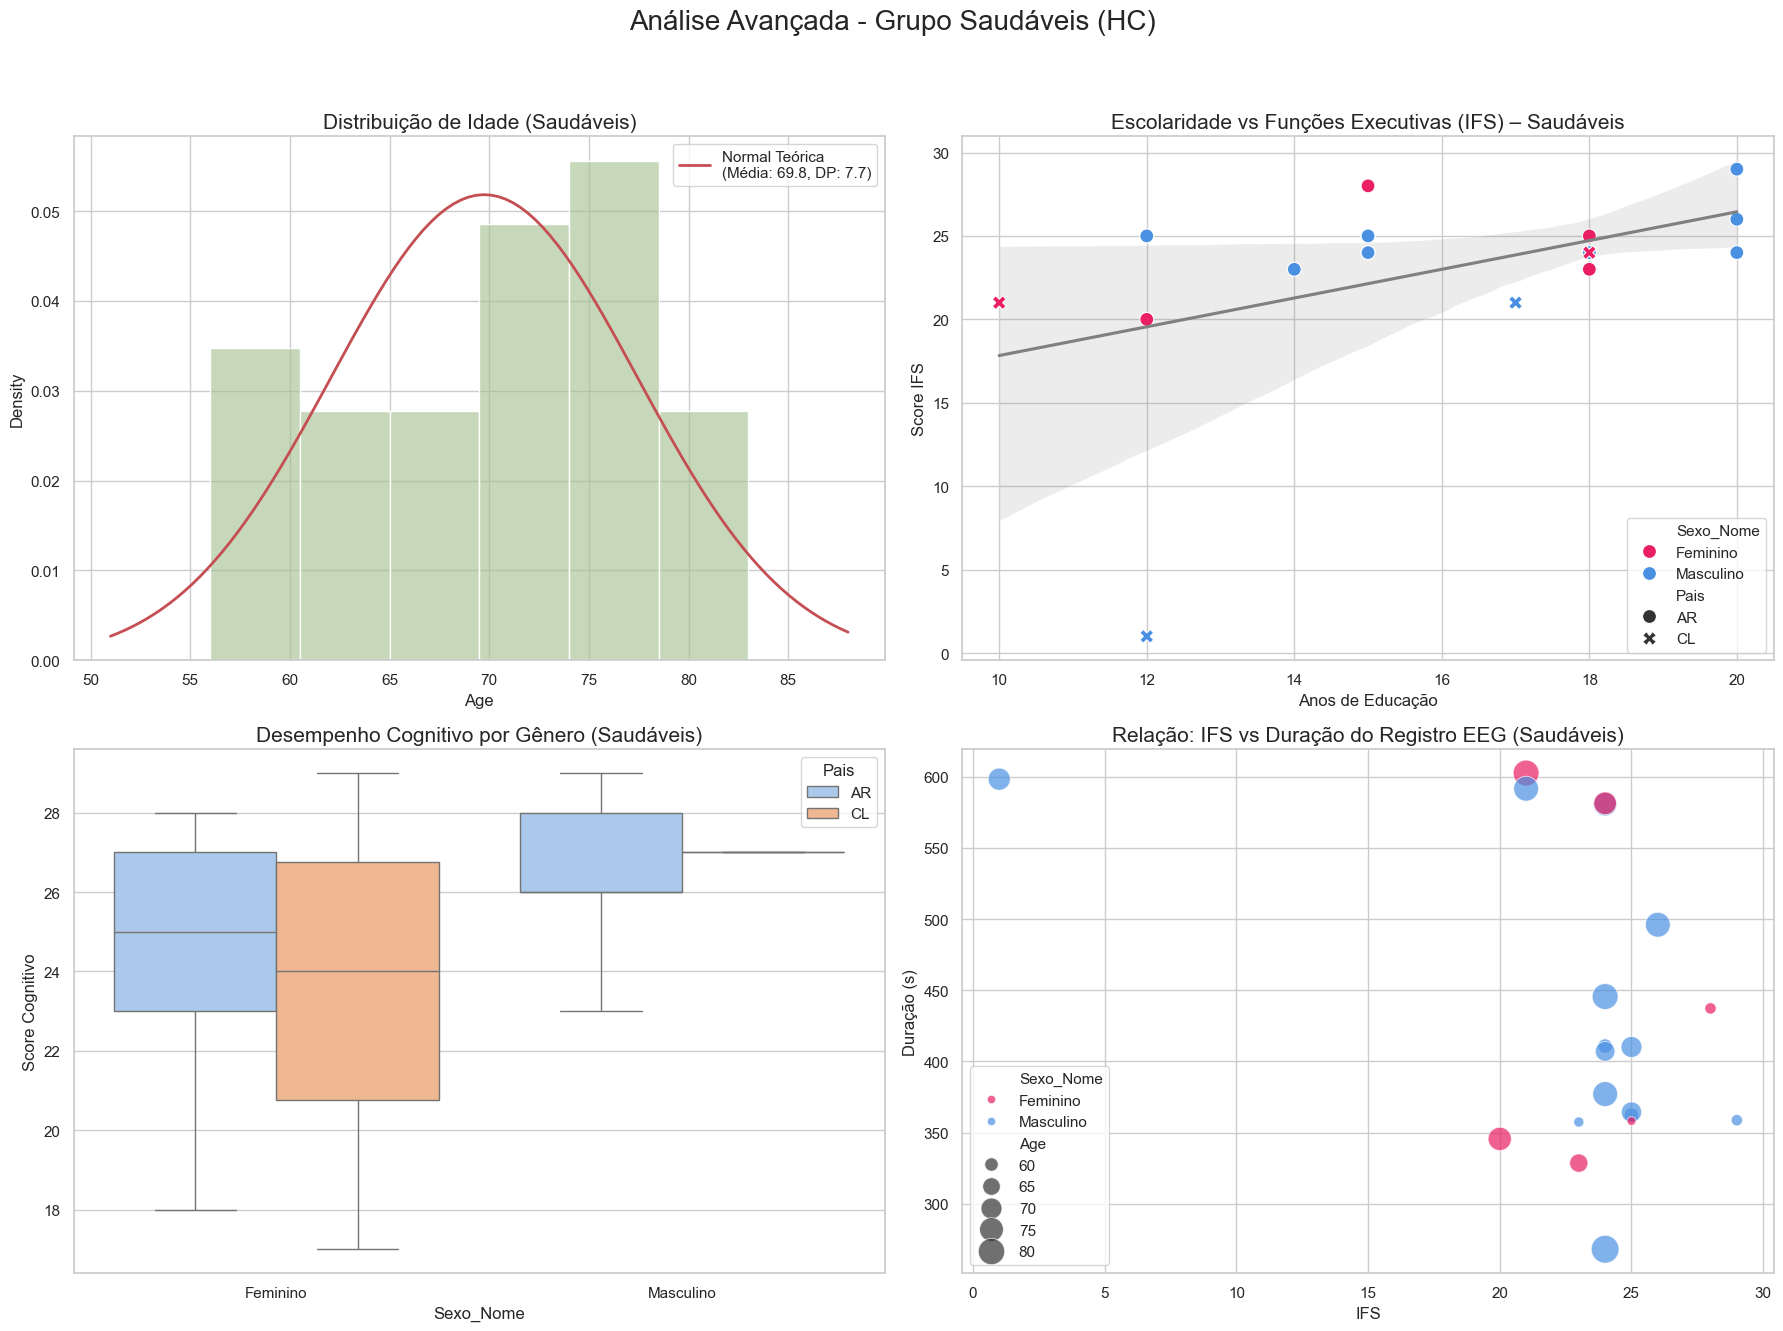

In [29]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import warnings

warnings.filterwarnings('ignore')

# 1. Caminho e carga do arquivo dos SAUDÁVEIS
caminho_raiz = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_hc"
file_path = os.path.join(caminho_raiz, "metadados_propios_eeg_hc.csv")

try:
    df = pd.read_csv(file_path)
    print("✅ Arquivo carregado. Colunas disponíveis:")
    print(df.columns.tolist())
    
    # Mapeamento inteligente de colunas (adapte se necessário)
    col_idade = 'Age' if 'Age' in df.columns else ('age' if 'age' in df.columns else None)
    col_sexo = 'sex' if 'sex' in df.columns else None
    col_educ = 'years_education' if 'years_education' in df.columns else ('education_years' if 'education_years' in df.columns else None)
    col_ifs = 'ifs_total_score' if 'ifs_total_score' in df.columns else None
    col_moca = 'moca_total' if 'moca_total' in df.columns else ('mmse_total' if 'mmse_total' in df.columns else None)
    col_pais = 'Pais' if 'Pais' in df.columns else None
    col_duracao = 'Duração (s)' if 'Duração (s)' in df.columns else None
    
    # Criar coluna de nome do sexo se disponível
    if col_sexo is not None:
        df['Sexo_Nome'] = df[col_sexo].map({0: 'Masculino', 1: 'Feminino'})
    else:
        df['Sexo_Nome'] = 'Desconhecido'
    
    # Configuração visual
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    paleta_sexo = {'Masculino': '#4A90E2', 'Feminino': '#E91E63', 'Desconhecido': '#AAAAAA'}
    
    # --- GRÁFICO 1: Teste de normalidade (idade, se disponível) ---
    if col_idade is not None:
        dados = df[col_idade].dropna()
        sns.histplot(dados, kde=False, stat="density", ax=axes[0,0], color='#A3BE8C', alpha=0.6)
        mu, std = dados.mean(), dados.std()
        x = np.linspace(dados.min() - 5, dados.max() + 5, 100)
        p = norm.pdf(x, mu, std)
        axes[0,0].plot(x, p, 'r', linewidth=2, label=f'Normal Teórica\n(Média: {mu:.1f}, DP: {std:.1f})')
        axes[0,0].set_title(f'Distribuição de Idade (Saudáveis)', fontsize=15)
        axes[0,0].legend()
    else:
        axes[0,0].text(0.5, 0.5, 'Coluna de idade não disponível', ha='center', va='center')
        axes[0,0].set_title('Idade não encontrada')
    
    # --- GRÁFICO 2: IFS vs Escolaridade (se ambas existirem) ---
    if col_ifs is not None and col_educ is not None:
        sns.regplot(data=df, x=col_educ, y=col_ifs, scatter=False, ax=axes[0,1], color='gray')
        sns.scatterplot(data=df, x=col_educ, y=col_ifs, hue='Sexo_Nome',
                        style=col_pais if col_pais else None, s=100, palette=paleta_sexo, ax=axes[0,1])
        axes[0,1].set_title('Escolaridade vs Funções Executivas (IFS) – Saudáveis', fontsize=15)
        axes[0,1].set_ylabel('Score IFS')
        axes[0,1].set_xlabel('Anos de Educação')
    else:
        axes[0,1].text(0.5, 0.5, 'Dados de IFS ou escolaridade ausentes', ha='center', va='center')
        axes[0,1].set_title('IFS vs Escolaridade – não disponível')
    
    # --- GRÁFICO 3: Cognição (MoCA/MMSE) por gênero ---
    if col_moca is not None and col_sexo is not None:
        sns.boxplot(data=df, x='Sexo_Nome', y=col_moca, hue=col_pais if col_pais else None, ax=axes[1,0], palette='pastel')
        axes[1,0].set_title('Desempenho Cognitivo por Gênero (Saudáveis)', fontsize=15)
        axes[1,0].set_ylabel('Score Cognitivo')
    else:
        axes[1,0].text(0.5, 0.5, 'Coluna cognitiva ou sexo ausente', ha='center', va='center')
        axes[1,0].set_title('Cognição por Gênero – não disponível')
    
    # --- GRÁFICO 4: IFS vs Duração do sinal (se disponíveis) ---
    if col_ifs is not None and col_duracao is not None:
        sns.scatterplot(data=df, x=col_ifs, y=col_duracao, hue='Sexo_Nome',
                        size=col_idade if col_idade else None, sizes=(40, 400), alpha=0.7, palette=paleta_sexo, ax=axes[1,1])
        axes[1,1].set_title('Relação: IFS vs Duração do Registro EEG (Saudáveis)', fontsize=15)
        axes[1,1].set_xlabel('IFS')
        axes[1,1].set_ylabel('Duração (s)')
    else:
        axes[1,1].text(0.5, 0.5, 'Colunas IFS ou Duração ausentes', ha='center', va='center')
        axes[1,1].set_title('IFS vs Duração – não disponível')
    
    plt.suptitle('Análise Avançada - Grupo Saudáveis (HC)', fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
except Exception as e:
    print(f"❌ Erro ao processar: {e}")

✅ Metadados carregados: 32 registros

🚀 Iniciando extração EEG para 32 sujeitos saudáveis...
  ✅ 5/32 sujeitos processados
  ✅ 10/32 sujeitos processados
  ✅ 15/32 sujeitos processados
  ✅ 20/32 sujeitos processados
  ✅ 25/32 sujeitos processados
  ✅ 30/32 sujeitos processados
  ✅ 32/32 sujeitos processados

💾 DataFrame com todas as features salvo em: C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_hc\df_eeg_features_hc.csv

  FAMÍLIA 1 — Potência Relativa por Banda
  Band_Delta                               Média 0.1808 ± 0.0640 | Min–Max 0.0589–0.3722 | CV 35.4%
  Band_Theta                               Mediana 0.1395 [0.1066–0.1932] | Min–Max 0.0855–0.2783 | CV 35.6%
  Band_Alpha                               Média 0.3906 ± 0.1222 | Min–Max 0.1582–0.6927 | CV 31.3%
  Band_Beta                                Média 0.2759 ± 0.0949 | Min–Max 0.1055–0.4713 | CV 34.4%

  FAMÍLIA 2 — Potência por Região × Banda
  Reg_Central_Delta                        Mediana 0.0026 [0.0017–

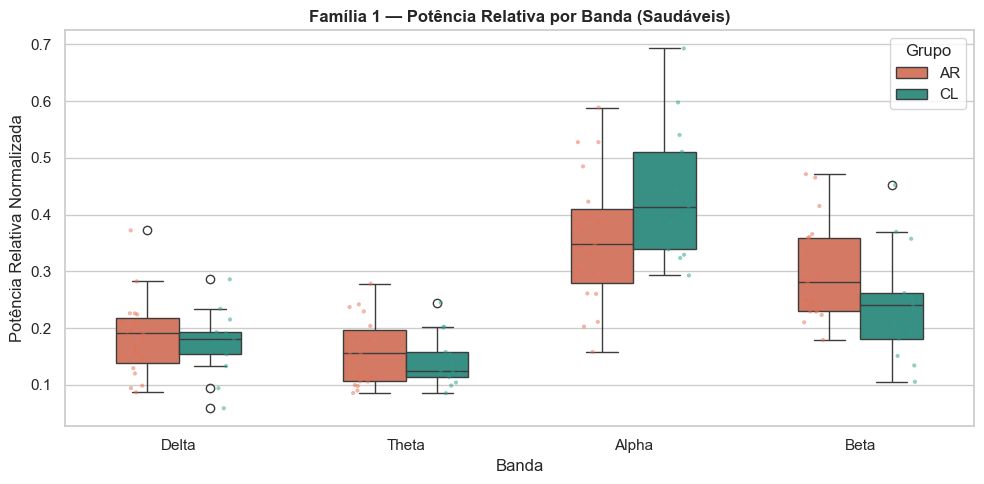

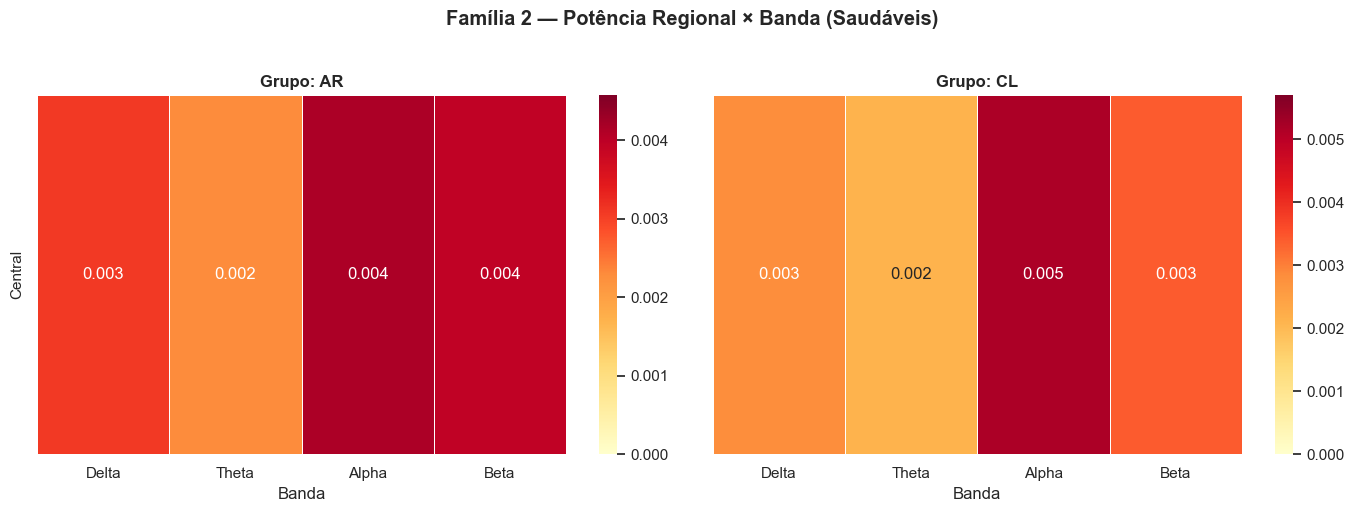

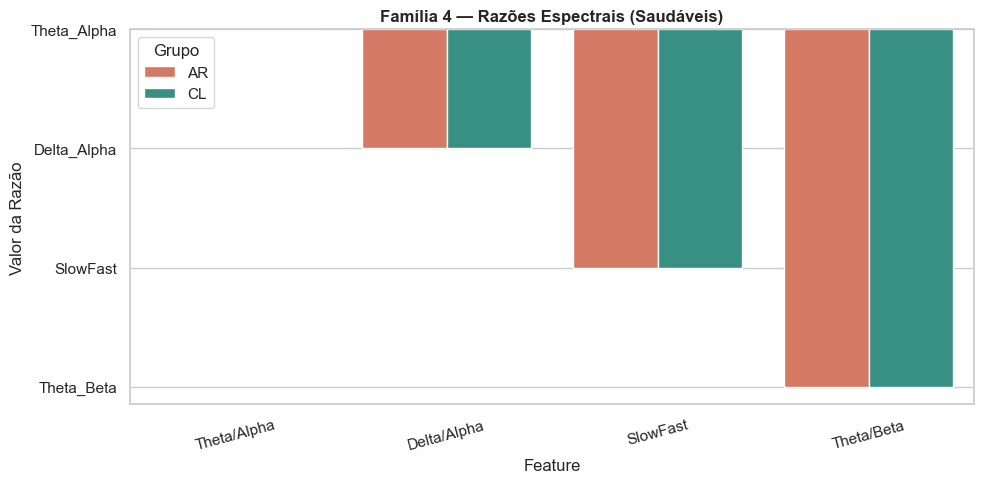

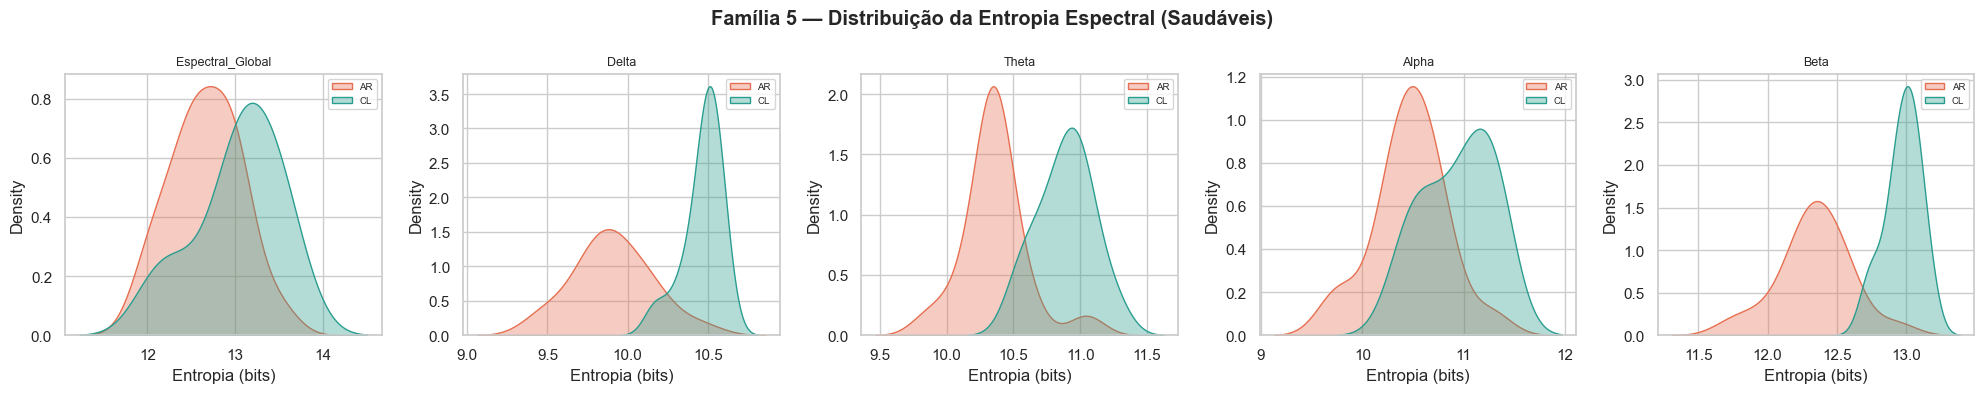

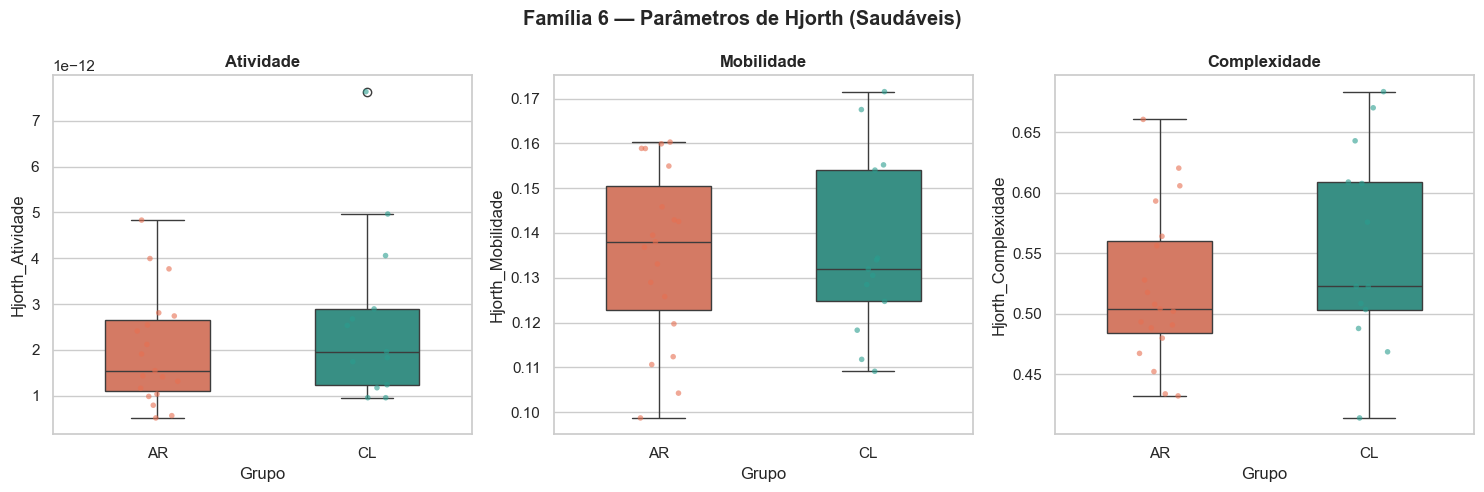

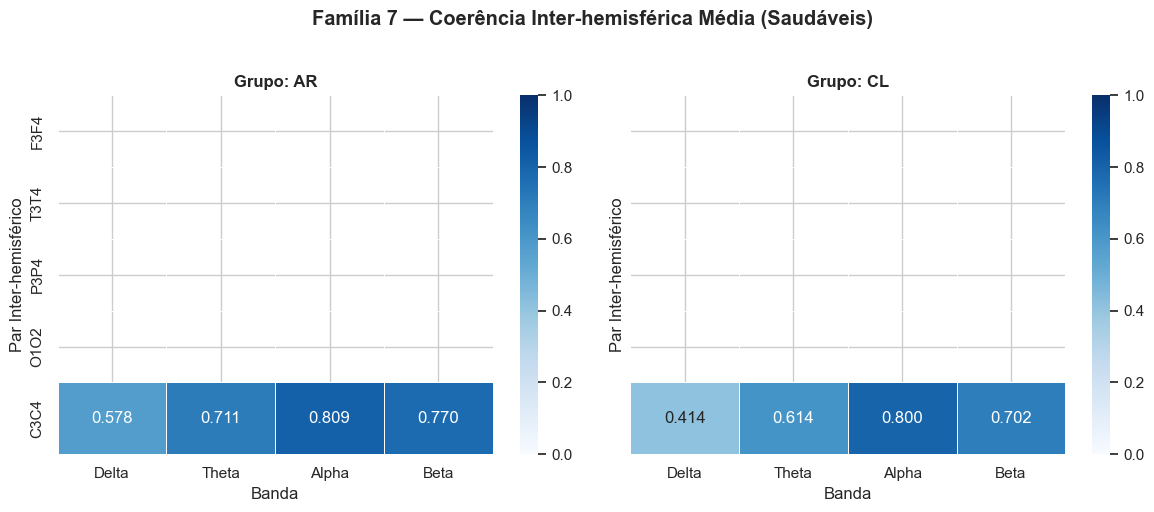

✅ Todas as figuras salvas (com sufixo _HC.png).


In [30]:
"""
================================================================================
  AUDITORIA NEUROFISIOLÓGICA — SAUDÁVEIS (HC)
  Extração e visualização de features EEG para grupo controle
================================================================================
  Famílias cobertas:
    1. Potência Relativa por Banda          (Delta, Theta, Alpha, Beta)
    2. Potência por Região Cortical         (Frontal, Temporal, Parietal, Occipital)
    3. Assimetria Alpha Frontal             (ln F4 – ln F3)
    4. Razões Espectrais                    (Theta/Alpha, Delta/Alpha, (Delta+Theta)/(Alpha+Beta))
    5. Entropia Espectral                   (por canal → média global)
    6. Parâmetros de Hjorth                 (Atividade, Mobilidade, Complexidade)
    7. Coerência Inter-hemisférica          (pares simétricos por banda)
================================================================================
"""

import mne
import numpy as np
import pandas as pd
import os
import glob
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.signal import coherence

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURAÇÃO GLOBAL – GRUPO SAUDÁVEIS
# ──────────────────────────────────────────────────────────────────────────────
CAMINHO_RAIZ = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_hc"
ARQUIVO_METADADOS = os.path.join(CAMINHO_RAIZ, "metadados_propios_eeg_hc.csv")
ARQUIVO_SAIDA_FEATURES = os.path.join(CAMINHO_RAIZ, "df_eeg_features_hc.csv")

BANDAS = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta":  (13, 30),
}

# Mapeamento de regiões para canais EEG padrão (10-20 / 10-10)
REGIOES = {
    "Frontal":   ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz", "AF3", "AF4"],
    "Temporal":  ["T3", "T4", "T5", "T6", "T7", "T8", "TP7", "TP8"],
    "Parietal":  ["P3", "P4", "P7", "P8", "Pz", "CP3", "CP4", "CPz"],
    "Occipital": ["O1", "O2", "Oz"],
    "Central":   ["C3", "C4", "Cz", "FC3", "FC4", "FCz"],
}

# Pares para coerência inter-hemisférica (esquerda → direita)
PARES_COERENCIA = [
    ("F3", "F4"), ("T3", "T4"), ("P3", "P4"), ("O1", "O2"), ("C3", "C4"),
]

PALETTE = {"AR": "#E76F51", "CL": "#2A9D8F"}   # AR e CL (mesmo do original)

# ──────────────────────────────────────────────────────────────────────────────
# UTILITÁRIOS
# ──────────────────────────────────────────────────────────────────────────────

def _stat_line(series: pd.Series) -> str:
    """Retorna média±DP ou mediana[IQR] dependendo da normalidade (Shapiro-Wilk)."""
    data = series.dropna()
    if len(data) < 3:
        return "n insuficiente"
    _, p = shapiro(data)
    cv = (data.std() / data.mean() * 100) if data.mean() != 0 else float("nan")
    if p > 0.05:
        return (f"Média {data.mean():.4f} ± {data.std():.4f} | "
                f"Min–Max {data.min():.4f}–{data.max():.4f} | CV {cv:.1f}%")
    else:
        return (f"Mediana {data.median():.4f} "
                f"[{data.quantile(0.25):.4f}–{data.quantile(0.75):.4f}] | "
                f"Min–Max {data.min():.4f}–{data.max():.4f} | CV {cv:.1f}%")


def _cabecalho(titulo: str) -> None:
    print(f"\n{'':=<70}")
    print(f"  {titulo}")
    print(f"{'':=<70}")


def _canais_disponiveis(raw: mne.io.BaseRaw, lista: list[str]) -> list[str]:
    """Filtra apenas os canais presentes no arquivo atual."""
    return [c for c in lista if c in raw.ch_names]


# ──────────────────────────────────────────────────────────────────────────────
# FUNÇÕES DE EXTRAÇÃO POR FAMÍLIA
# ──────────────────────────────────────────────────────────────────────────────

def extrair_potencia_banda(raw: mne.io.BaseRaw) -> dict:
    """Família 1 — Potência relativa global por banda."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)
    psd_total = np.sum(psds, axis=-1, keepdims=True)

    feats = {}
    for banda, (fmin, fmax) in BANDAS.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        pot_rel = (np.sum(psds[:, mask], axis=-1) / psd_total[:, 0]).mean()
        feats[f"Band_{banda}"] = float(pot_rel)
    return feats


def extrair_potencia_regional(raw: mne.io.BaseRaw) -> dict:
    """Família 2 — Potência relativa por região cortical × banda."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)
    psd_total = psds.sum()

    feats = {}
    for regiao, canais in REGIOES.items():
        ch_ok = _canais_disponiveis(raw, canais)
        if not ch_ok:
            continue
        idxs = [raw.ch_names.index(c) for c in ch_ok]
        psds_reg = psds[idxs, :]
        for banda, (fmin, fmax) in BANDAS.items():
            mask = (freqs >= fmin) & (freqs <= fmax)
            pot_rel = np.sum(psds_reg[:, mask]) / psd_total
            feats[f"Reg_{regiao}_{banda}"] = float(pot_rel)
    return feats


def extrair_assimetria_alpha(raw: mne.io.BaseRaw) -> dict:
    """Família 3 — Assimetria Alpha Frontal: ln(F4) – ln(F3)."""
    feats = {}
    for par_esq, par_dir in [("F3", "F4"), ("O1", "O2")]:
        if par_esq not in raw.ch_names or par_dir not in raw.ch_names:
            continue
        psd_obj = raw.compute_psd(
            method="multitaper", fmin=8, fmax=13,
            picks=[par_esq, par_dir], verbose=False
        )
        psds, _ = psd_obj.get_data(return_freqs=True)
        ln_esq = np.log(psds[0].mean() + 1e-12)
        ln_dir = np.log(psds[1].mean() + 1e-12)
        nome = "Front" if par_esq == "F3" else "Occip"
        feats[f"Assimetria_Alpha_{nome}"] = float(ln_dir - ln_esq)
    return feats


def extrair_razoes_espectrais(raw: mne.io.BaseRaw) -> dict:
    """Família 4 — Razões espectrais sensíveis a disfunções cognitivas."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)

    def pot(fmin, fmax):
        mask = (freqs >= fmin) & (freqs <= fmax)
        return psds[:, mask].sum(axis=-1).mean()

    delta = pot(*BANDAS["Delta"])
    theta = pot(*BANDAS["Theta"])
    alpha = pot(*BANDAS["Alpha"])
    beta  = pot(*BANDAS["Beta"])

    feats = {
        "Razao_Theta_Alpha":      float(theta / (alpha + 1e-12)),
        "Razao_Delta_Alpha":      float(delta / (alpha + 1e-12)),
        "Razao_SlowFast":         float((delta + theta) / (alpha + beta + 1e-12)),
        "Razao_Theta_Beta":       float(theta / (beta + 1e-12)),
    }
    return feats


def extrair_entropia_espectral(raw: mne.io.BaseRaw) -> dict:
    """Família 5 — Entropia espectral (média global e por banda)."""
    psd_obj = raw.compute_psd(method="multitaper", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd_obj.get_data(return_freqs=True)

    p = psds / (psds.sum(axis=-1, keepdims=True) + 1e-12)
    ent_por_canal = -np.sum(p * np.log2(p + 1e-12), axis=-1)

    feats = {"Entropia_Espectral_Global": float(ent_por_canal.mean())}

    for banda, (fmin, fmax) in BANDAS.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        p_banda = psds[:, mask] / (psds[:, mask].sum(axis=-1, keepdims=True) + 1e-12)
        ent_banda = -np.sum(p_banda * np.log2(p_banda + 1e-12), axis=-1)
        feats[f"Entropia_{banda}"] = float(ent_banda.mean())

    return feats


def extrair_hjorth(raw: mne.io.BaseRaw) -> dict:
    """Família 6 — Parâmetros de Hjorth (média global sobre todos os canais)."""
    data = raw.get_data()

    atividade = np.var(data, axis=-1).mean()

    d1 = np.diff(data, axis=-1)
    mobilidade = np.sqrt(np.var(d1, axis=-1) / (np.var(data, axis=-1) + 1e-12)).mean()

    d2 = np.diff(d1, axis=-1)
    mob_d1 = np.sqrt(np.var(d2, axis=-1) / (np.var(d1, axis=-1) + 1e-12)).mean()
    complexidade = mob_d1 / (mobilidade + 1e-12)

    return {
        "Hjorth_Atividade":    float(atividade),
        "Hjorth_Mobilidade":   float(mobilidade),
        "Hjorth_Complexidade": float(complexidade),
    }


def extrair_coerencia(raw: mne.io.BaseRaw) -> dict:
    """Família 7 — Coerência inter-hemisférica por par × banda."""
    sfreq = raw.info["sfreq"]
    feats = {}

    for ch_esq, ch_dir in PARES_COERENCIA:
        if ch_esq not in raw.ch_names or ch_dir not in raw.ch_names:
            continue
        sig_esq = raw.get_data(picks=[ch_esq])[0]
        sig_dir = raw.get_data(picks=[ch_dir])[0]

        f_coh, Cxy = coherence(sig_esq, sig_dir, fs=sfreq, nperseg=int(sfreq * 2))

        for banda, (fmin, fmax) in BANDAS.items():
            mask = (f_coh >= fmin) & (f_coh <= fmax)
            coh_media = Cxy[mask].mean() if mask.any() else np.nan
            par_nome = f"{ch_esq}{ch_dir}"
            feats[f"Coh_{par_nome}_{banda}"] = float(coh_media)

    return feats


# ──────────────────────────────────────────────────────────────────────────────
# LOOP PRINCIPAL DE EXTRAÇÃO
# ──────────────────────────────────────────────────────────────────────────────

def extrair_todas_features(df_final: pd.DataFrame) -> pd.DataFrame:
    todos_os_sets = glob.glob(
        os.path.join(CAMINHO_RAIZ, "**", "*.set"), recursive=True
    )
    mapeamento = {os.path.basename(p): p for p in todos_os_sets}
    df_final = df_final.copy()
    df_final["Caminho_Completo"] = df_final["Arquivo"].map(mapeamento)

    print(f"\n🚀 Iniciando extração EEG para {len(df_final)} sujeitos saudáveis...")
    features_list = []

    EXTRACTORS = [
        ("Potência/Banda",     extrair_potencia_banda),
        ("Potência/Região",    extrair_potencia_regional),
        ("Assimetria Alpha",   extrair_assimetria_alpha),
        ("Razões Espectrais",  extrair_razoes_espectrais),
        ("Entropia Espectral", extrair_entropia_espectral),
        ("Hjorth",             extrair_hjorth),
        ("Coerência",          extrair_coerencia),
    ]

    for idx, row in df_final.iterrows():
        caminho = row.get("Caminho_Completo")
        if pd.isna(caminho) or not os.path.exists(str(caminho)):
            print(f"  ⚠️  Arquivo não encontrado: {row['Arquivo']}")
            continue
        try:
            raw = mne.io.read_raw_eeglab(caminho, preload=True, verbose=False)
            raw.filter(0.5, 45, verbose=False)

            sujeito_feats = {"Arquivo": row["Arquivo"]}
            for nome_fam, fn in EXTRACTORS:
                try:
                    sujeito_feats.update(fn(raw))
                except Exception as e_fam:
                    print(f"    ⚠️  [{nome_fam}] {row['Arquivo']}: {e_fam}")

            features_list.append(sujeito_feats)
            n = idx + 1
            if n % 5 == 0 or n == len(df_final):
                print(f"  ✅ {n}/{len(df_final)} sujeitos processados")

        except Exception as e:
            print(f"  ❌ Erro crítico em {row['Arquivo']}: {e}")

    df_eeg = pd.DataFrame(features_list)
    return pd.merge(df_final, df_eeg, on="Arquivo", how="left")


# ──────────────────────────────────────────────────────────────────────────────
# AUDITORIA ESTATÍSTICA POR FAMÍLIA
# ──────────────────────────────────────────────────────────────────────────────

FAMILIAS_COLS = {
    "1 — Potência Relativa por Banda": [f"Band_{b}" for b in BANDAS],
    "2 — Potência por Região × Banda": [
        f"Reg_{r}_{b}" for r in REGIOES for b in BANDAS
    ],
    "3 — Assimetria Alpha Frontal": [
        "Assimetria_Alpha_Front", "Assimetria_Alpha_Occip"
    ],
    "4 — Razões Espectrais": [
        "Razao_Theta_Alpha", "Razao_Delta_Alpha",
        "Razao_SlowFast",    "Razao_Theta_Beta",
    ],
    "5 — Entropia Espectral": [
        "Entropia_Espectral_Global"
    ] + [f"Entropia_{b}" for b in BANDAS],
    "6 — Parâmetros de Hjorth": [
        "Hjorth_Atividade", "Hjorth_Mobilidade", "Hjorth_Complexidade"
    ],
    "7 — Coerência Inter-hemisférica": [
        f"Coh_{ch_e}{ch_d}_{b}"
        for ch_e, ch_d in PARES_COERENCIA
        for b in BANDAS
    ],
}


def auditoria_estatistica(df: pd.DataFrame) -> None:
    for familia, cols in FAMILIAS_COLS.items():
        cols_ok = [c for c in cols if c in df.columns]
        if not cols_ok:
            continue
        _cabecalho(f"FAMÍLIA {familia}")
        for col in cols_ok:
            linha = _stat_line(df[col])
            print(f"  {col:<40} {linha}")


# ──────────────────────────────────────────────────────────────────────────────
# VISUALIZAÇÕES (com nomes adaptados para HC)
# ──────────────────────────────────────────────────────────────────────────────

def _melt_familia(df: pd.DataFrame, cols: list[str], valor: str) -> pd.DataFrame:
    cols_ok = [c for c in cols if c in df.columns]
    return df.melt(id_vars=["Pais"], value_vars=cols_ok,
                   var_name="Feature", value_name=valor)


def plot_familia_1(df: pd.DataFrame) -> None:
    cols = [f"Band_{b}" for b in BANDAS]
    df_m = _melt_familia(df, cols, "Potência Relativa")
    df_m["Banda"] = df_m["Feature"].str.replace("Band_", "", regex=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df_m, x="Banda", y="Potência Relativa",
                hue="Pais", palette=PALETTE, ax=ax, width=0.55,
                order=list(BANDAS.keys()))
    sns.stripplot(data=df_m, x="Banda", y="Potência Relativa",
                  hue="Pais", palette=PALETTE, ax=ax,
                  dodge=True, size=3, alpha=0.5,
                  order=list(BANDAS.keys()), legend=False)
    ax.set_title("Família 1 — Potência Relativa por Banda (Saudáveis)", fontweight="bold")
    ax.set_ylabel("Potência Relativa Normalizada")
    ax.legend(title="Grupo")
    plt.tight_layout()
    plt.savefig("audit_F1_potencia_banda_HC.png", dpi=150)
    plt.show()


def plot_familia_2(df: pd.DataFrame) -> None:
    grupos = df["Pais"].unique()
    fig, axes = plt.subplots(1, len(grupos), figsize=(14, 5), sharey=True)
    if len(grupos) == 1:
        axes = [axes]

    for ax, grupo in zip(axes, grupos):
        df_g = df[df["Pais"] == grupo]
        matriz = {}
        for regiao in REGIOES:
            for banda in BANDAS:
                col = f"Reg_{regiao}_{banda}"
                if col in df_g.columns:
                    matriz.setdefault(regiao, {})[banda] = df_g[col].mean()
        df_heat = pd.DataFrame(matriz).T[list(BANDAS.keys())]
        sns.heatmap(df_heat, ax=ax, annot=True, fmt=".3f",
                    cmap="YlOrRd", linewidths=0.5,
                    vmin=0, vmax=df_heat.values.max() * 1.1)
        ax.set_title(f"Grupo: {grupo}", fontweight="bold")
        ax.set_xlabel("Banda")

    fig.suptitle("Família 2 — Potência Regional × Banda (Saudáveis)",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("audit_F2_potencia_regional_HC.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_familia_3(df: pd.DataFrame) -> None:
    cols = ["Assimetria_Alpha_Front", "Assimetria_Alpha_Occip"]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return
    df_m = _melt_familia(df, cols_ok, "Assimetria (ln R – ln L)")
    df_m["Região"] = df_m["Feature"].str.replace("Assimetria_Alpha_", "", regex=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.violinplot(data=df_m, x="Região", y="Assimetria (ln R – ln L)",
                   hue="Pais", palette=PALETTE, split=True, inner="quart", ax=ax)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="Simetria")
    ax.set_title("Família 3 — Assimetria Alpha (Saudáveis)", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("audit_F3_assimetria_alpha_HC.png", dpi=150)
    plt.show()


def plot_familia_4(df: pd.DataFrame) -> None:
    cols = ["Razao_Theta_Alpha", "Razao_Delta_Alpha",
            "Razao_SlowFast", "Razao_Theta_Beta"]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return
    df_m = _melt_familia(df, cols_ok, "Razão")
    df_m["Razão"] = df_m["Feature"].str.replace("Razao_", "", regex=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=df_m, x="Feature", y="Razão",
                hue="Pais", palette=PALETTE,
                estimator=np.median, errorbar=("pi", 50), ax=ax)
    ax.set_xticklabels([c.replace("Razao_", "").replace("_", "/")
                         for c in cols_ok], rotation=15)
    ax.set_title("Família 4 — Razões Espectrais (Saudáveis)", fontweight="bold")
    ax.set_ylabel("Valor da Razão")
    ax.legend(title="Grupo")
    plt.tight_layout()
    plt.savefig("audit_F4_razoes_espectrais_HC.png", dpi=150)
    plt.show()


def plot_familia_5(df: pd.DataFrame) -> None:
    cols = ["Entropia_Espectral_Global"] + [f"Entropia_{b}" for b in BANDAS]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return

    n = len(cols_ok)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_ok):
        for grupo, cor in PALETTE.items():
            subset = df[df["Pais"] == grupo][col].dropna()
            if len(subset) > 1:
                sns.kdeplot(subset, ax=ax, label=grupo, color=cor, fill=True, alpha=0.35)
        ax.set_title(col.replace("Entropia_", ""), fontsize=9)
        ax.set_xlabel("Entropia (bits)")
        ax.legend(fontsize=7)

    fig.suptitle("Família 5 — Distribuição da Entropia Espectral (Saudáveis)",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig("audit_F5_entropia_HC.png", dpi=150)
    plt.show()


def plot_familia_6(df: pd.DataFrame) -> None:
    cols = ["Hjorth_Atividade", "Hjorth_Mobilidade", "Hjorth_Complexidade"]
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return

    fig, axes = plt.subplots(1, len(cols_ok), figsize=(5 * len(cols_ok), 5))
    if len(cols_ok) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_ok):
        sns.boxplot(data=df, x="Pais", y=col,
                    palette=PALETTE, ax=ax, width=0.5)
        sns.stripplot(data=df, x="Pais", y=col,
                      palette=PALETTE, ax=ax, size=4, alpha=0.6)
        ax.set_title(col.replace("Hjorth_", ""), fontweight="bold")
        ax.set_xlabel("Grupo")

    fig.suptitle("Família 6 — Parâmetros de Hjorth (Saudáveis)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("audit_F6_hjorth_HC.png", dpi=150)
    plt.show()


def plot_familia_7(df: pd.DataFrame) -> None:
    pares = [f"{ch_e}{ch_d}" for ch_e, ch_d in PARES_COERENCIA]
    grupos = df["Pais"].unique()
    bandas_list = list(BANDAS.keys())

    fig, axes = plt.subplots(1, len(grupos), figsize=(6 * len(grupos), 5),
                             sharey=True)
    if len(grupos) == 1:
        axes = [axes]

    for ax, grupo in zip(axes, grupos):
        df_g = df[df["Pais"] == grupo]
        matriz = pd.DataFrame(index=pares, columns=bandas_list, dtype=float)
        for par in pares:
            for banda in bandas_list:
                col = f"Coh_{par}_{banda}"
                if col in df_g.columns:
                    matriz.loc[par, banda] = df_g[col].mean()
        sns.heatmap(matriz.astype(float), ax=ax, annot=True, fmt=".3f",
                    cmap="Blues", linewidths=0.5, vmin=0, vmax=1)
        ax.set_title(f"Grupo: {grupo}", fontweight="bold")
        ax.set_xlabel("Banda")
        ax.set_ylabel("Par Inter-hemisférico")

    fig.suptitle("Família 7 — Coerência Inter-hemisférica Média (Saudáveis)",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("audit_F7_coerencia_HC.png", dpi=150, bbox_inches="tight")
    plt.show()


def plotar_todas_familias(df: pd.DataFrame) -> None:
    print("\n📊 Gerando visualizações para saudáveis...")
    plot_familia_1(df)
    plot_familia_2(df)
    plot_familia_3(df)
    plot_familia_4(df)
    plot_familia_5(df)
    plot_familia_6(df)
    plot_familia_7(df)
    print("✅ Todas as figuras salvas (com sufixo _HC.png).")


# ──────────────────────────────────────────────────────────────────────────────
# PONTO DE ENTRADA PRINCIPAL
# ──────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Carrega os metadados dos saudáveis (gerado anteriormente)
    if not os.path.exists(ARQUIVO_METADADOS):
        raise FileNotFoundError(f"Arquivo não encontrado: {ARQUIVO_METADADOS}\n"
                                "Execute primeiro o script de metadados para saudáveis.")
    
    df_metadados = pd.read_csv(ARQUIVO_METADADOS)
    print(f"✅ Metadados carregados: {len(df_metadados)} registros")
    
    # Extrai as features EEG (pode demorar)
    df_completo = extrair_todas_features(df_metadados)
    
    # Salva o DataFrame enriquecido
    df_completo.to_csv(ARQUIVO_SAIDA_FEATURES, index=False)
    print(f"\n💾 DataFrame com todas as features salvo em: {ARQUIVO_SAIDA_FEATURES}")
    
    # Auditoria estatística
    auditoria_estatistica(df_completo)
    
    # Geração dos gráficos
    plotar_todas_familias(df_completo)

✅ Colunas EEG disponíveis: ['Band_Theta', 'Band_Alpha', 'Razao_Theta_Alpha', 'Entropia_Espectral_Global', 'Hjorth_Mobilidade', 'Hjorth_Complexidade']
✅ Colunas clínicas disponíveis: ['Age', 'years_education', 'moca_total', 'ifs_total_score']


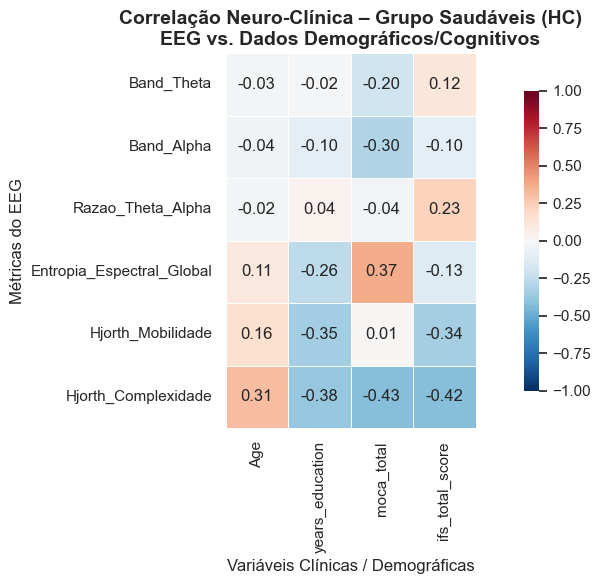

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Carregar o DataFrame completo (com features EEG + metadados)
# Se você já tem o df na memória, pule esta linha.
df = pd.read_csv(r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_hc\df_eeg_features_hc.csv")

# 1. Verificar quais colunas EEG e clínicas estão disponíveis
cols_eeg_candidatas = [
    'Band_Theta', 'Band_Alpha', 'Razao_Theta_Alpha',
    'Entropia_Espectral_Global', 'Hjorth_Mobilidade', 'Hjorth_Complexidade'
]

cols_clinicas_candidatas = ['Age', 'years_education', 'moca_total', 'ifs_total_score']

# Verificar existência
cols_eeg = [c for c in cols_eeg_candidatas if c in df.columns]
cols_clinicas = [c for c in cols_clinicas_candidatas if c in df.columns]

if not cols_eeg or not cols_clinicas:
    print("Colunas faltando:")
    print("EEG esperadas:", cols_eeg_candidatas)
    print("EEG presentes:", cols_eeg)
    print("Clínicas esperadas:", cols_clinicas_candidatas)
    print("Clínicas presentes:", cols_clinicas)
    raise ValueError("Algumas colunas necessárias não foram encontradas no DataFrame.")

print(f"✅ Colunas EEG disponíveis: {cols_eeg}")
print(f"✅ Colunas clínicas disponíveis: {cols_clinicas}")

# 2. Calcular matriz de correlação de Spearman (mais robusta para dados não normais)
corr_matrix = df[cols_eeg + cols_clinicas].corr(method='spearman')

# 3. Subset apenas cruzamento EEG vs clínica
subset_corr = corr_matrix.loc[cols_eeg, cols_clinicas]

# 4. Plotar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(subset_corr, annot=True, cmap='RdBu_r', center=0,
            fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlação Neuro-Clínica – Grupo Saudáveis (HC)\nEEG vs. Dados Demográficos/Cognitivos',
          fontweight='bold', fontsize=14)
plt.xlabel('Variáveis Clínicas / Demográficas', fontsize=12)
plt.ylabel('Métricas do EEG', fontsize=12)
plt.tight_layout()
plt.savefig("correlacao_EEG_clinica_HC.png", dpi=150)
plt.show()

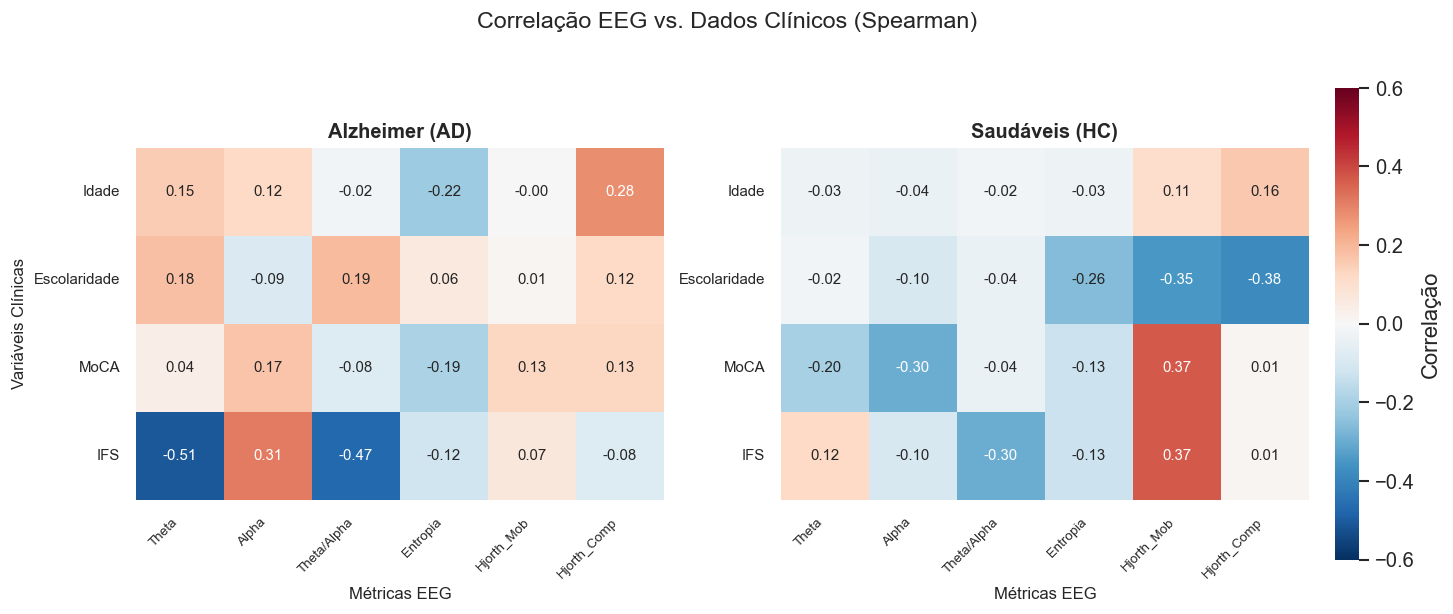

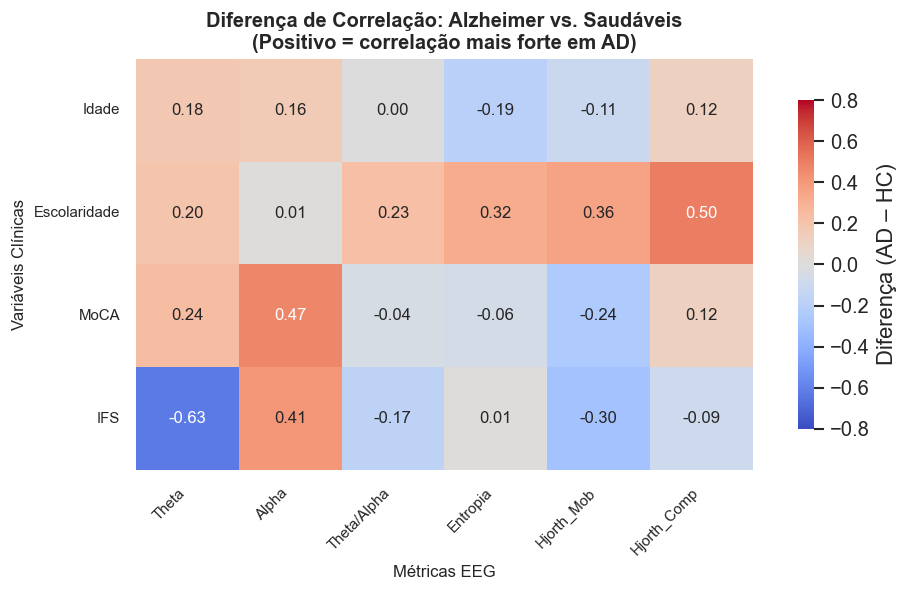


📊 DIFERENÇA DE CORRELAÇÃO (AD – HC)
              Theta  Alpha  Theta/Alpha  Entropia  Hjorth_Mob  Hjorth_Comp
Idade          0.18   0.16         0.00     -0.19       -0.11         0.12
Escolaridade   0.20   0.01         0.23      0.32        0.36         0.50
MoCA           0.24   0.47        -0.04     -0.06       -0.24         0.12
IFS           -0.63   0.41        -0.17      0.01       -0.30        -0.09

📌 Interpretação:
   • Valores positivos → correlação mais forte (ou menos negativa) no Alzheimer
   • Valores negativos → correlação mais forte (ou menos positiva) nos Saudáveis

✅ Arquivo 'diferencas_correlacao_AD_HC.csv' salvo.


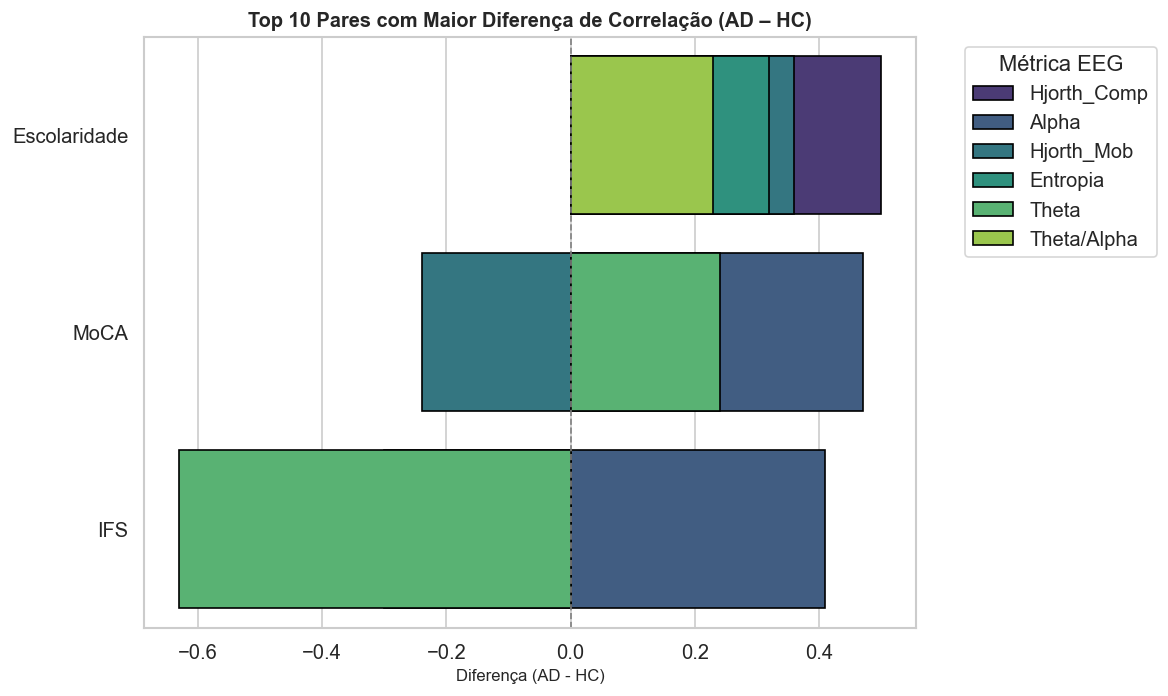

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 1. Dados das matrizes (já validadas)
# =============================================================================

# Métricas EEG (features)
eeg_metrics = [
    'Theta', 'Alpha', 'Theta/Alpha',
    'Entropia', 'Hjorth_Mob', 'Hjorth_Comp'
]

# Nomes completos para referência (usaremos os abreviados nos gráficos)
eeg_full = {
    'Theta': 'Band Theta',
    'Alpha': 'Band Alpha',
    'Theta/Alpha': 'Ratio θ/α',
    'Entropia': 'Entropia Espectral',
    'Hjorth_Mob': 'Hjorth Mobilidade',
    'Hjorth_Comp': 'Hjorth Complexidade'
}

# Variáveis clínicas
clinical_vars = ['Idade', 'Escolaridade', 'MoCA', 'IFS']
clinical_full = {
    'Idade': 'Age (anos)',
    'Escolaridade': 'Educação (anos)',
    'MoCA': 'MoCA total',
    'IFS': 'IFS total'
}

# Matriz Alzheimer (AD) - valores originais na ordem: Theta, Alpha, Theta/Alpha, Entropia, Hjorth_Mob, Hjorth_Comp
data_ad = {
    'Idade':         [0.15,  0.12, -0.02, -0.22, -0.00,  0.28],
    'Escolaridade':  [0.18, -0.09,  0.19,  0.06,  0.01,  0.12],
    'MoCA':          [0.04,  0.17, -0.08, -0.19,  0.13,  0.13],
    'IFS':           [-0.51, 0.31, -0.47, -0.12,  0.07, -0.08]
}
df_ad = pd.DataFrame(data_ad, index=eeg_metrics).T   # transpor: linhas = clínicas, colunas = EEG

# Matriz Saudáveis (HC)
data_hc = {
    'Idade':         [-0.03, -0.04, -0.02, -0.03,  0.11,  0.16],
    'Escolaridade':  [-0.02, -0.10, -0.04, -0.26, -0.35, -0.38],
    'MoCA':          [-0.20, -0.30, -0.04, -0.13,  0.37,  0.01],
    'IFS':           [ 0.12, -0.10, -0.30, -0.13,  0.37,  0.01]
}
df_hc = pd.DataFrame(data_hc, index=eeg_metrics).T

# =============================================================================
# 2. Configuração de estilo (clean)
# =============================================================================
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 120

# =============================================================================
# 3. Heatmaps lado a lado (corrigido)
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Alzheimer
sns.heatmap(df_ad, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.6, vmax=0.6, square=True, cbar=False,
            annot_kws={'size': 9}, ax=ax1)
ax1.set_title('Alzheimer (AD)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Métricas EEG', fontsize=10)
ax1.set_ylabel('Variáveis Clínicas', fontsize=10)
ax1.set_xticklabels(eeg_metrics, rotation=45, ha='right', fontsize=8)
ax1.set_yticklabels(clinical_vars, rotation=0, fontsize=9)

# Saudáveis
sns.heatmap(df_hc, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.6, vmax=0.6, square=True, cbar=True,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8, 'label': 'Correlação'},
            ax=ax2)
ax2.set_title('Saudáveis (HC)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Métricas EEG', fontsize=10)
ax2.set_ylabel('')
ax2.set_xticklabels(eeg_metrics, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(clinical_vars, rotation=0, fontsize=9)

fig.suptitle('Correlação EEG vs. Dados Clínicos (Spearman)', fontsize=14, y=1.02)
plt.savefig('correlacao_AD_HC_ladoalado.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. Heatmap de diferenças (AD - HC)
# =============================================================================
diff_matrix = df_ad - df_hc

plt.figure(figsize=(9, 5))
sns.heatmap(diff_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-0.8, vmax=0.8, square=True,
            annot_kws={'size': 10}, cbar_kws={'shrink': 0.8, 'label': 'Diferença (AD – HC)'})
plt.title('Diferença de Correlação: Alzheimer vs. Saudáveis\n(Positivo = correlação mais forte em AD)',
          fontsize=12, fontweight='bold')
plt.xlabel('Métricas EEG', fontsize=10)
plt.ylabel('Variáveis Clínicas', fontsize=10)
plt.xticks(ticks=np.arange(len(eeg_metrics))+0.5, labels=eeg_metrics, rotation=45, ha='right', fontsize=9)
plt.yticks(ticks=np.arange(len(clinical_vars))+0.5, labels=clinical_vars, rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('diferenca_correlacao_AD_HC.png', dpi=150)
plt.show()

# =============================================================================
# 5. Tabela de diferenças com destaque
# =============================================================================
print("\n" + "="*70)
print("📊 DIFERENÇA DE CORRELAÇÃO (AD – HC)")
print("="*70)
print(diff_matrix.round(2).to_string())
print("\n📌 Interpretação:")
print("   • Valores positivos → correlação mais forte (ou menos negativa) no Alzheimer")
print("   • Valores negativos → correlação mais forte (ou menos positiva) nos Saudáveis")

# Salvar CSV
diff_matrix.round(2).to_csv("diferencas_correlacao_AD_HC.csv", index=True)
print("\n✅ Arquivo 'diferencas_correlacao_AD_HC.csv' salvo.")

# =============================================================================
# 6. Gráfico de barras das 10 maiores diferenças (em módulo)
# =============================================================================
# Empilhar a matriz de diferenças
diff_stacked = diff_matrix.stack().reset_index()
diff_stacked.columns = ['Clinica', 'EEG', 'Diferenca']
diff_stacked['AbsDiff'] = diff_stacked['Diferenca'].abs()
top10 = diff_stacked.nlargest(10, 'AbsDiff').sort_values('Diferenca', ascending=False)

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=top10, x='Diferenca', y='Clinica', hue='EEG', dodge=False,
                   palette='viridis', edgecolor='black')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Top 10 Pares com Maior Diferença de Correlação (AD – HC)', fontsize=12, fontweight='bold')
plt.xlabel('Diferença (AD - HC)', fontsize=10)
plt.ylabel('')
plt.legend(title='Métrica EEG', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('top10_diferencas.png', dpi=150)
plt.show()

✅ Arquivo carregado com sucesso!
Total: 35 pacientes
Grupo
HC    19
AD    16
Name: count, dtype: int64

--- TESTE A - Mann-Whitney ---
                     Feature      U  p_valor  significativo  mediana_AD  \
0                 Band_Theta  120.0   0.2969          False      0.1753   
1                 Band_Alpha  135.0   0.5848          False      0.3128   
2          Razao_Theta_Alpha  133.0   0.5401          False      0.6281   
3  Entropia_Espectral_Global   81.0   0.0196           True     12.4212   
4          Hjorth_Mobilidade  189.0   0.2268          False      0.1707   
5        Hjorth_Complexidade  142.0   0.7531          False      1.2471   

   mediana_HC  
0      0.2233  
1      0.3346  
2      0.7934  
3     12.9805  
4      0.1573  
5      1.2292  


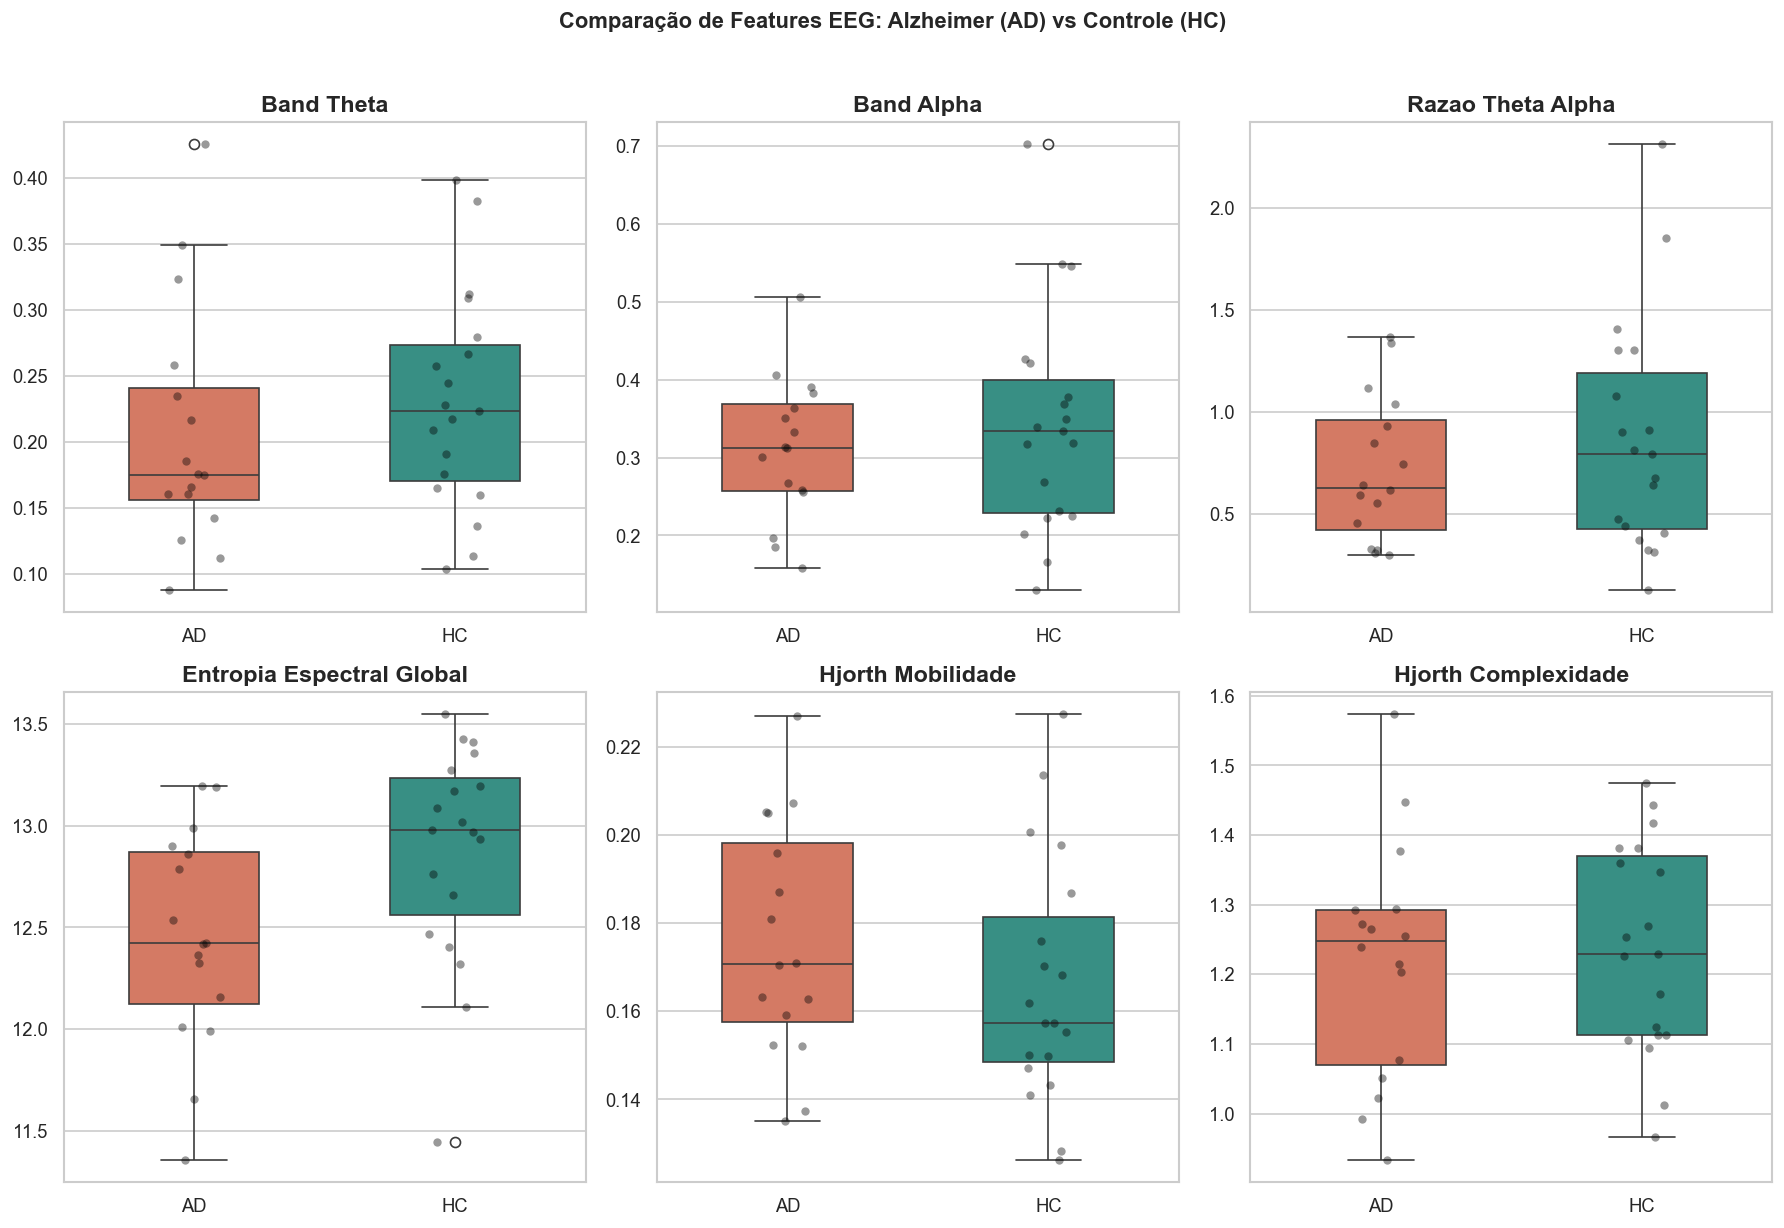


--- TESTE B - Permutação: ifs_total_score vs Band_Theta ---
Diferença observada (AD - HC) = 0.076, p-valor = 0.7564


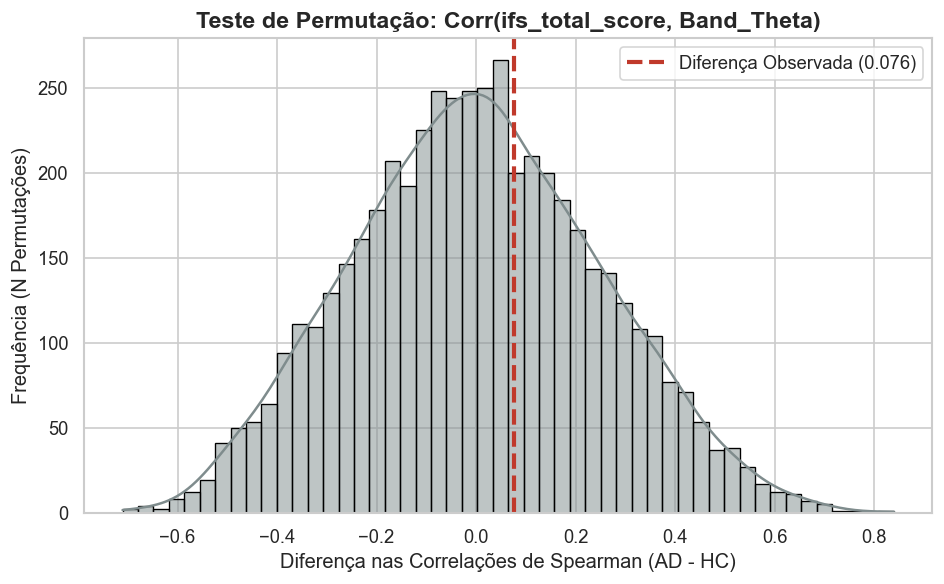

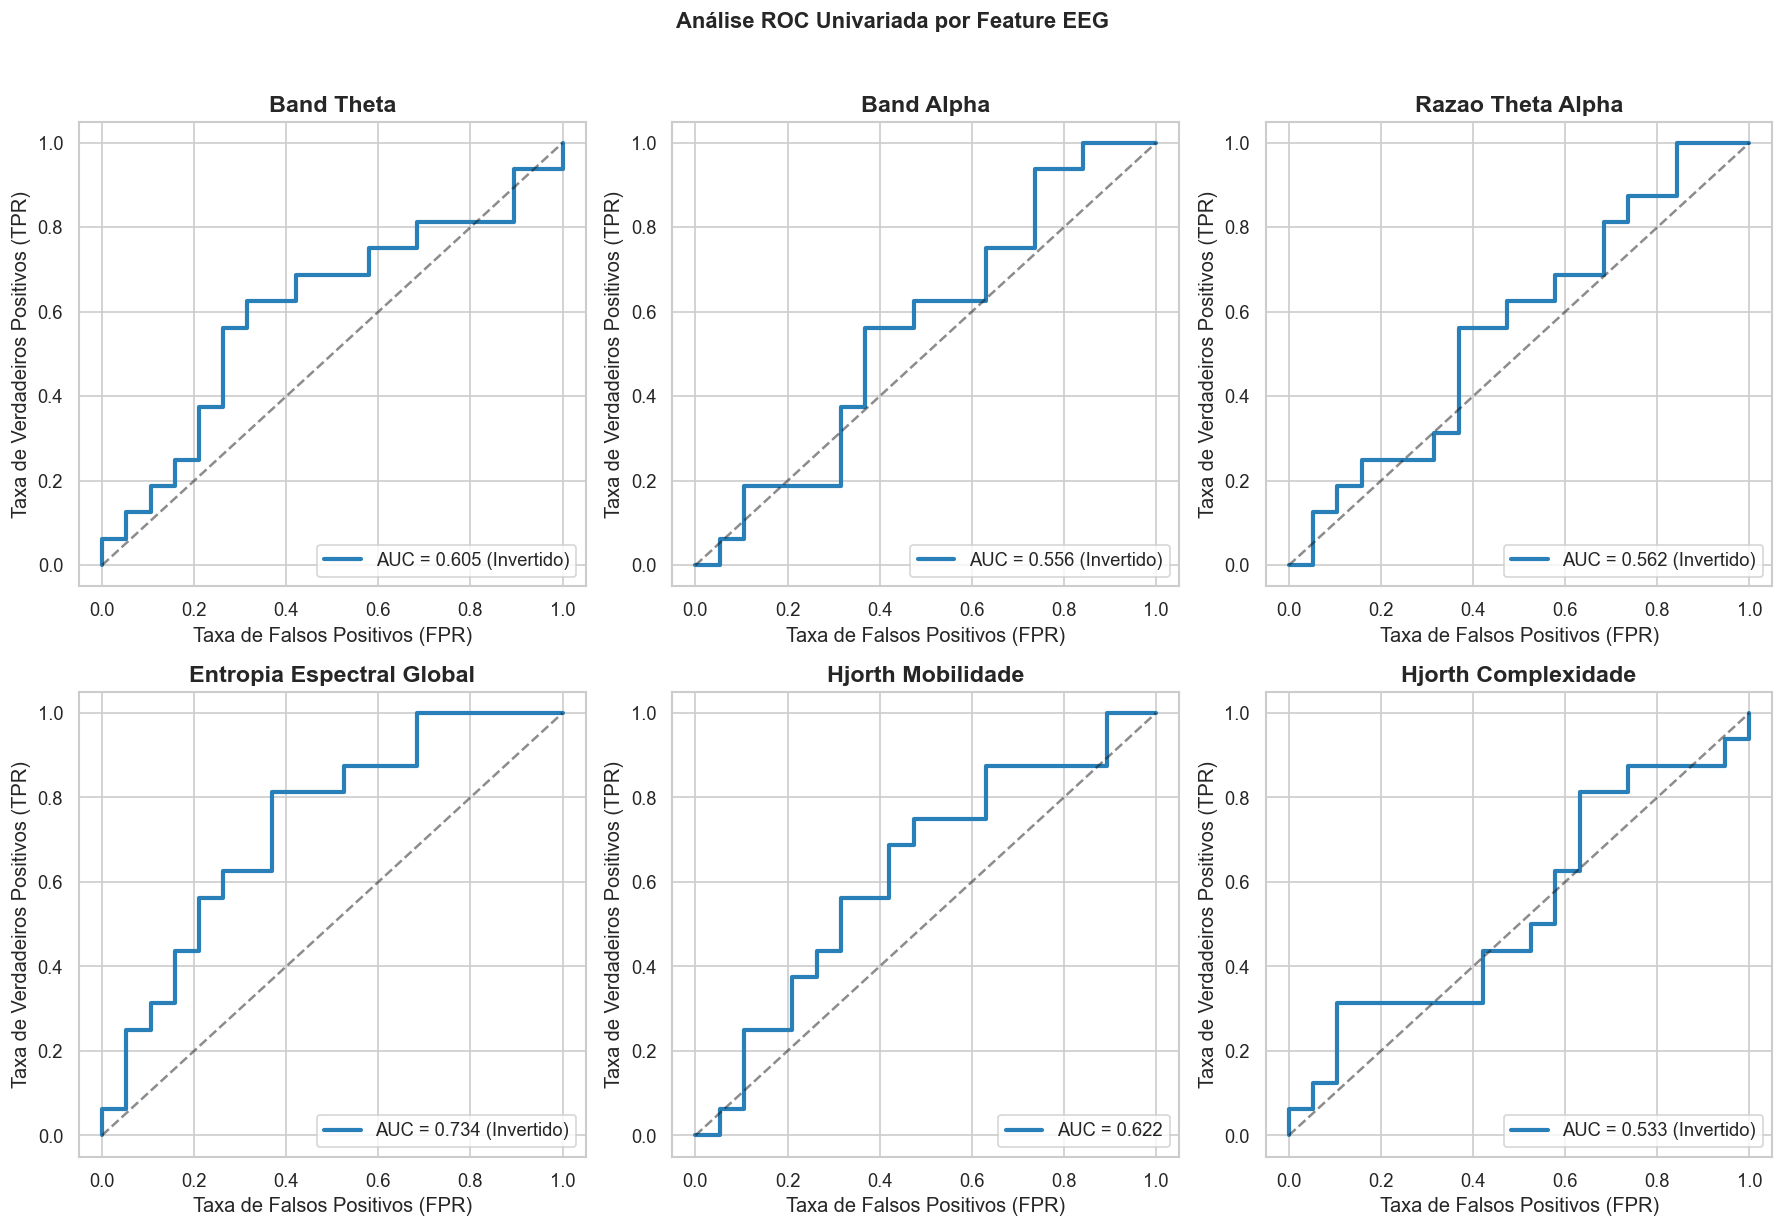


✅ Script finalizado! Gráficos salvos com alta resolução (300 dpi).


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.metrics import roc_curve, roc_auc_score
import os

# Configuração de estilo para os gráficos (Padrão para artigos)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ============================================
# 1. CARREGAR OS DADOS REAIS
# ============================================
caminho_real = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer\df_auditado_final_alzheimer.csv"

try:
    df = pd.read_csv(caminho_real)
    print("✅ Arquivo carregado com sucesso!")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ Não achou o arquivo em: {caminho_real}")

# Mapeando os Grupos (AR = Alzheimer / CL = Controle Saudável)
if 'Grupo' not in df.columns:
    if 'Pais' in df.columns:
        df['Grupo'] = df['Pais'].map({'AR': 'AD', 'CL': 'HC'})
    else:
        raise ValueError("❌ Coluna 'Pais' não encontrada para separar os grupos.")

print(f"Total: {len(df)} pacientes")
print(df['Grupo'].value_counts())

# ============================================
# 2. FEATURES EEG
# ============================================
features = [
    'Band_Theta', 'Band_Alpha', 'Razao_Theta_Alpha',
    'Entropia_Espectral_Global', 'Hjorth_Mobilidade', 'Hjorth_Complexidade'
]

# Verificar se as colunas existem
missing = [f for f in features if f not in df.columns]
if missing:
    raise ValueError(f"❌ Colunas ausentes no DataFrame: {missing}")

# ============================================
# TESTE A - Mann-Whitney U e Boxplots Isolados
# ============================================
def mannwhitney_test(df, features, grupo_col='Grupo', g1='AD', g2='HC'):
    resultados = []
    for f in features:
        x = df[df[grupo_col]==g1][f].dropna()
        y = df[df[grupo_col]==g2][f].dropna()
        
        # Teste U de Mann-Whitney
        u, p = mannwhitneyu(x, y, alternative='two-sided')
        resultados.append({
            'Feature': f,
            'U': u,
            'p_valor': p,
            'significativo': p < 0.05,
            'mediana_AD': x.median(),
            'mediana_HC': y.median()
        })
    return pd.DataFrame(resultados)

print("\n--- TESTE A - Mann-Whitney ---")
df_mw = mannwhitney_test(df, features)
print(df_mw.round(4))

# PLOT: Grid de Boxplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

paleta_grupos = {'AD': '#E76F51', 'HC': '#2A9D8F'}

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='Grupo', y=feature, ax=axes[i], palette=paleta_grupos, width=0.5)
    sns.stripplot(data=df, x='Grupo', y=feature, color='black', alpha=0.4, ax=axes[i], size=5)
    axes[i].set_title(feature.replace('_', ' '), fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.suptitle('Comparação de Features EEG: Alzheimer (AD) vs Controle (HC)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots_mannwhitney_isolados.png', bbox_inches='tight', dpi=300)
plt.show()

# ============================================
# TESTE B - Permutação (Correlação Clínica)
# ============================================
def permutacao_correlacao(df, grupo_col, var_clinica, feat_eeg, n_perm=5000):
    # Isola apenas dados válidos para não quebrar a correlação
    df_clean = df.dropna(subset=[var_clinica, feat_eeg]).copy()
    
    df1 = df_clean[df_clean[grupo_col]=='AD']
    df2 = df_clean[df_clean[grupo_col]=='HC']
    
    if len(df1) < 2 or len(df2) < 2:
        return np.nan, np.nan, []

    r1_obs, _ = spearmanr(df1[var_clinica], df1[feat_eeg])
    r2_obs, _ = spearmanr(df2[var_clinica], df2[feat_eeg])
    diff_obs = r1_obs - r2_obs
    
    diffs_perm = []
    
    for _ in range(n_perm):
        grupo_perm = df_clean[grupo_col].sample(frac=1, replace=False).values
        df_clean['grupo_perm'] = grupo_perm
        
        r1_perm, _ = spearmanr(df_clean[df_clean['grupo_perm']=='AD'][var_clinica],
                               df_clean[df_clean['grupo_perm']=='AD'][feat_eeg])
        r2_perm, _ = spearmanr(df_clean[df_clean['grupo_perm']=='HC'][var_clinica],
                               df_clean[df_clean['grupo_perm']=='HC'][feat_eeg])
        diffs_perm.append(r1_perm - r2_perm)
        
    diffs_perm = np.array(diffs_perm)
    diffs_perm = diffs_perm[~np.isnan(diffs_perm)]
    
    if len(diffs_perm) == 0:
         return diff_obs, np.nan, []

    p_val = (np.sum(np.abs(diffs_perm) >= np.abs(diff_obs)) + 1) / (len(diffs_perm) + 1)
    return diff_obs, p_val, diffs_perm

var_clin = 'ifs_total_score'
feat_eeg = 'Band_Theta'

if var_clin in df.columns:
    diff_obs, p_val_perm, dist = permutacao_correlacao(df, 'Grupo', var_clin, feat_eeg)
    print(f"\n--- TESTE B - Permutação: {var_clin} vs {feat_eeg} ---")
    print(f"Diferença observada (AD - HC) = {diff_obs:.3f}, p-valor = {p_val_perm:.4f}")

    if len(dist) > 0:
        plt.figure(figsize=(8, 5))
        sns.histplot(dist, bins=50, color='#7f8c8d', edgecolor='black', kde=True)
        plt.axvline(diff_obs, color='#c0392b', linestyle='--', linewidth=2.5, label=f'Diferença Observada ({diff_obs:.3f})')
        plt.title(f'Teste de Permutação: Corr({var_clin}, {feat_eeg})', fontweight='bold')
        plt.xlabel('Diferença nas Correlações de Spearman (AD - HC)')
        plt.ylabel('Frequência (N Permutações)')
        plt.legend()
        plt.tight_layout()
        plt.savefig('permutacao_corrigido.png', dpi=300)
        plt.show()

# ============================================
# TESTE C - Curvas ROC Univariadas
# ============================================
df_model = df.dropna(subset=features).copy()
y_true = (df_model['Grupo'] == 'AD').astype(int)

# PLOT: Grid para as curvas ROC
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, f in enumerate(features):
    auc_val = roc_auc_score(y_true, df_model[f])
    fpr, tpr, _ = roc_curve(y_true, df_model[f])
    
    # Inverte a curva se a AUC for menor que 0.5 (ocorre quando valores MENORES indicam AD, ex: Band_Alpha)
    if auc_val < 0.5:
        auc_val = roc_auc_score(y_true, -df_model[f])
        fpr, tpr, _ = roc_curve(y_true, -df_model[f])
        sinal = " (Invertido)"
    else:
        sinal = ""
    
    axes[i].plot(fpr, tpr, label=f'AUC = {auc_val:.3f}{sinal}', color='#2980b9', linewidth=2.5)
    axes[i].plot([0,1], [0,1], 'k--', alpha=0.5)
    axes[i].set_title(f.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel('Taxa de Falsos Positivos (FPR)')
    axes[i].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
    axes[i].legend(loc='lower right')

plt.suptitle('Análise ROC Univariada por Feature EEG', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_univariada_isoladas.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n✅ Script finalizado! Gráficos salvos com alta resolução (300 dpi).")